# PCOS Prediction — Enhanced Methodology

This notebook implements a rigorous, literature-aligned pipeline for PCOS prediction using the Kaggle clinical dataset.
It builds progressively from a corrected baseline through four targeted improvements, each benchmarked independently.

## Methodological fixes vs original notebooks

1. **SMOTE leakage fixed** — SMOTE is applied only inside each CV training fold, never to the full dataset before splitting
2. **SVM/KNN scaling fixed** — distance/kernel-based models are wrapped in a Pipeline with StandardScaler
3. **Stratified k-fold CV** — 5-fold stratified CV throughout; no single lucky/unlucky splits
4. **Identifier columns dropped** — Sl. No and Patient File No. removed before modelling
5. **Clinical metric priority** — recall on the PCOS-positive class is reported alongside accuracy; F1 and AUC included

## Improvements added (Sections 3b, 3c, 5b, 7b, 7c)

| Improvement | Section | Literature justification |
|---|---|---|
| **Mutual Information feature selection** (k=18) | 3c | Chelliah et al. — MI-Stacking: 98% accuracy; Patil & Jalnekar — 94.98% |
| **Boruta feature selection** | 3c | Patil & Jalnekar — XGBoost+Boruta: 95.89% accuracy |
| **Union feature set** (MI ∪ Boruta, multicollinearity removed) | 3c | Patil & Jalnekar — union gives best AUC across most classifiers |
| **SMOTE variant comparison** | 5b | Majumdar et al. — KMeans-SMOTE + Extra Trees: 92.9% |
| **Advanced stacking classifier** (RF+XGB+LGBM+CAT → LR) | 7c | Rahman et al. — SMOTE+Stacking: 98%; Patil & Jalnekar — MI-Stacking AUC 0.9894 |

## Models evaluated

| Model | Type | Notes |
|---|---|---|
| Logistic Regression (LR) | Linear | Baseline linear classifier |
| K-Nearest Neighbours (KNN) | Instance-based | Requires scaling; k tuned via GridSearch |
| Narrow Neural Network (NNN) | Neural network | MLPClassifier (64→32); early stopping prevents overfitting |
| Support Vector Machine (SVM) | Kernel-based | Requires scaling; RBF kernel |
| Naive Bayes (NB) | Probabilistic | High recall but low precision; not recommended as primary model |
| Decision Tree (DT) | Tree | Interpretable baseline; prone to overfitting |
| Random Forest (RF) | Ensemble (bagging) | Robust; strong on tabular clinical data |
| AdaBoost (ADA) | Ensemble (boosting) | Adaptive boosting over Decision Trees |
| Gradient Boosting (GBM) | Ensemble (boosting) | sklearn GBM |
| XGBoost (XGB) | Ensemble (boosting) | State-of-the-art on tabular data |
| LightGBM (LGBM) | Ensemble (boosting) | Faster XGBoost alternative; leaf-wise growth |
| CatBoost (CAT) | Ensemble (boosting) | Handles mixed types natively |
| Stacking Classifier | Meta-ensemble | RF + XGB + LGBM + CAT → Logistic Regression meta-learner |


## 1. Imports and Setup

In [45]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier          # Narrow Neural Network (NNN)
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    VotingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap

warnings.filterwarnings('ignore')
np.random.seed(42)

print('All libraries loaded successfully.')

# ── Additional imports for Section 3b/3c improvements ──────────────────────
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from boruta import BorutaPy
from imblearn.over_sampling import BorderlineSMOTE, KMeansSMOTE
try:
    from matplotlib_venn import venn2 as _venn2
    _HAS_VENN = True
except ImportError:
    _HAS_VENN = False


All libraries loaded successfully.


## 2. Data Acquisition

In [90]:
df = pd.read_csv(os.path.join('data', 'PCOS_extended_dataset.csv'))
print(f'Dataset shape: {df.shape}')
df.info()

Dataset shape: (2000, 44)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  2000 non-null   int64  
 1   Patient File No.        2000 non-null   int64  
 2   PCOS (Y/N)              2000 non-null   int64  
 3    Age (yrs)              2000 non-null   int64  
 4   Weight (Kg)             2000 non-null   float64
 5   Height(Cm)              2000 non-null   float64
 6   BMI                     2000 non-null   float64
 7   Blood Group             2000 non-null   int64  
 8   Pulse rate(bpm)         2000 non-null   int64  
 9   RR (breaths/min)        2000 non-null   int64  
 10  Hb(g/dl)                2000 non-null   float64
 11  Cycle(R/I)              2000 non-null   int64  
 12  Cycle length(days)      2000 non-null   int64  
 13  Marraige Status (Yrs)   1997 non-null   float64
 14  Pregnant(Y/N)           2

In [91]:
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,193,193,0,30,69.979147,167.708055,23.185569,12,72,22,...,1,0.0,1,105.483401,76.096379,2,4,10.0,13.0,6.176029
1,360,360,0,36,63.711688,154.055877,25.441392,13,70,18,...,1,0.0,1,115.883740,79.117243,2,3,13.0,11.0,6.824718
2,10,10,0,36,51.848631,149.059804,23.928264,15,80,20,...,0,0.0,0,112.219711,80.919417,1,1,14.0,17.0,2.568691
3,278,278,1,29,66.893988,148.628036,27.894935,15,72,18,...,0,0.0,1,104.619624,69.902681,1,1,12.0,14.0,9.962732
4,71,71,0,33,52.536198,150.767409,23.079564,13,72,18,...,0,0.0,0,99.175454,70.330461,5,2,11.5,4.7,6.655190


## 3. Data Preprocessing

In [92]:
# Drop unnamed index columns and identifier columns that carry no predictive signal
# FIX: 'Sl. No' and 'Patient File No.' are row identifiers — keeping them could create
# spurious correlations, especially with tree-based models.
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.drop(columns=['Sl. No', 'Patient File No.'], errors='ignore')

# Sanitize feature names to avoid downstream encoding issues with LightGBM
# LightGBM can fail on feature names containing special JSON characters such as
# parentheses, slashes, or percent signs.
df = df.rename(columns={"PCOS (Y/N)": 'PCOS_YN'})
df.columns = (
    df.columns
      .str.strip()
      .str.replace(r'[^0-9a-zA-Z_]', '_', regex=True)
      .str.replace(r'_+', '_', regex=True)
      .str.strip('_')
)

# Drop rows with missing values
df = df.dropna()

# Encode object-type categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

print(f'Shape after cleaning: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')

Shape after cleaning: (1997, 42)
Missing values: 0


In [93]:
# Define target and feature matrix
TARGET = 'PCOS_YN'
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Features: {X.shape[1]}')
print(f'\nClass distribution (raw):')
print(y.value_counts())
print(f'\nClass balance ratio: {y.value_counts(normalize=True).round(3).to_dict()}')

Features: 41

Class distribution (raw):
PCOS_YN
0    1392
1     605
Name: count, dtype: int64

Class balance ratio: {0: 0.697, 1: 0.303}


## 4. Exploratory Data Analysis

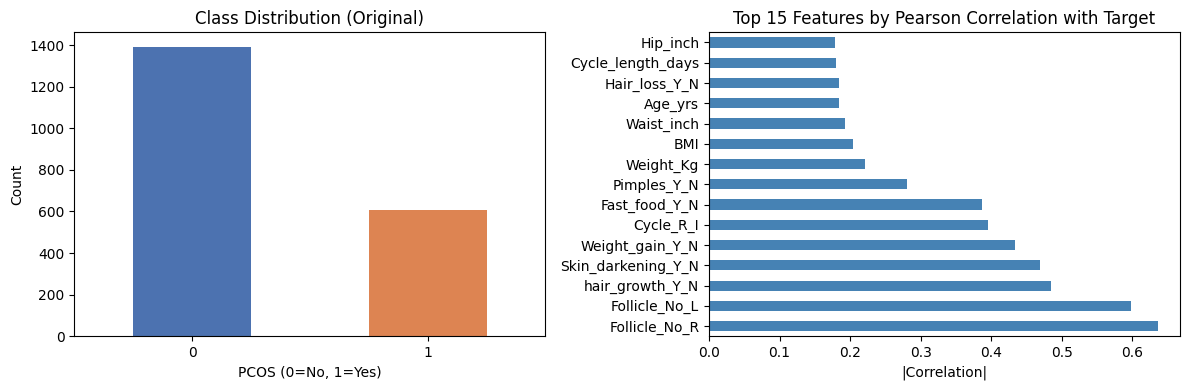


Top 10 correlated features:
Follicle_No_R         0.636072
Follicle_No_L         0.597698
hair_growth_Y_N       0.484909
Skin_darkening_Y_N    0.468764
Weight_gain_Y_N       0.434062
Cycle_R_I             0.396033
Fast_food_Y_N         0.387619
Pimples_Y_N           0.281379
Weight_Kg             0.221183
BMI                   0.203916
dtype: float64


In [94]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y.value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Class Distribution (Original)')
axes[0].set_xlabel('PCOS (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Correlation with target
correlations = X.corrwith(y).abs().sort_values(ascending=False)
correlations.head(15).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Features by Pearson Correlation with Target')
axes[1].set_xlabel('|Correlation|')

plt.tight_layout()
plt.show()

print('\nTop 10 correlated features:')
print(correlations.head(10))

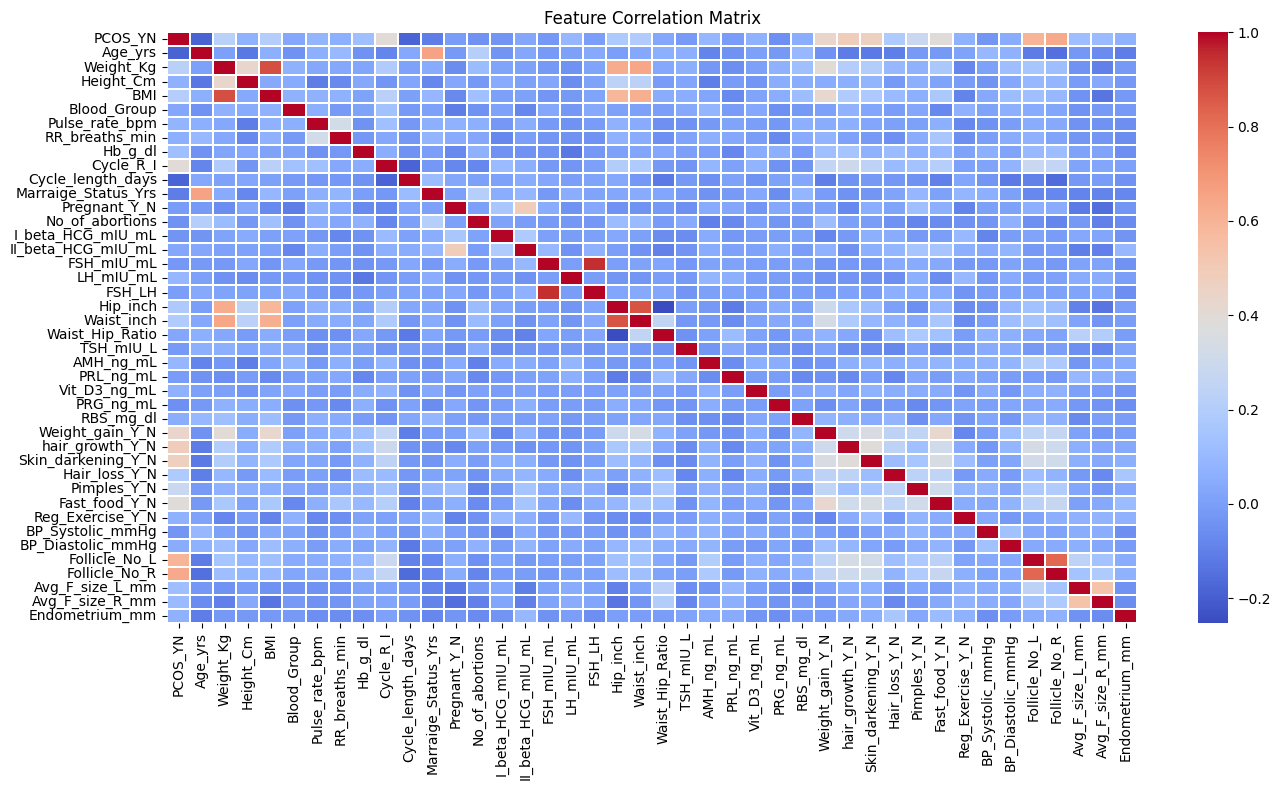

In [95]:
# Correlation heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, linewidths=0.3)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 5. Train/Test Split

> **Important:** The train/test split happens here, **before** any SMOTE or scaling. This is the correct order.
> Applying SMOTE before the split leaks synthetic training samples into the test set and inflates reported accuracy.

In [96]:
# Hold out 20% as a final test set — stratified to preserve class ratio
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set:  {X_train_full.shape[0]} samples')
print(f'Test set:      {X_test.shape[0]} samples')
print(f'\nTest class distribution:')
print(y_test.value_counts())

Training set:  1597 samples
Test set:      400 samples

Test class distribution:
PCOS_YN
0    279
1    121
Name: count, dtype: int64


## 3b. Feature Selection (Mutual Information, Boruta, Union)

Removing irrelevant and redundant features improves SMOTE quality and model generalisation.
Three methods are compared; a union is then formed and multicollinear pairs removed.

| Method | Basis | Best result in literature |
|---|---|---|
| **Mutual Information (MI)** | Filter — statistical dependency | Stacking + MI → 94.98% acc, AUC 0.9894 (Patil & Jalnekar) |
| **Boruta** | Wrapper — RF shadow-feature test | XGBoost + Boruta → 95.89% acc (Patil & Jalnekar) |
| **Union (MI ∪ Boruta)** | Hybrid | Avoids losing features flagged by only one method |

> All selectors are **fitted on `X_train_full` only**.


MI selected 18 features:
['Cycle_R_I', 'Cycle_length_days', 'I_beta_HCG_mIU_mL', 'II_beta_HCG_mIU_mL', 'FSH_mIU_mL', 'LH_mIU_mL', 'FSH_LH', 'TSH_mIU_L', 'AMH_ng_mL', 'PRL_ng_mL', 'Vit_D3_ng_mL', 'PRG_ng_mL', 'Weight_gain_Y_N', 'hair_growth_Y_N', 'Skin_darkening_Y_N', 'Fast_food_Y_N', 'Follicle_No_L', 'Follicle_No_R']


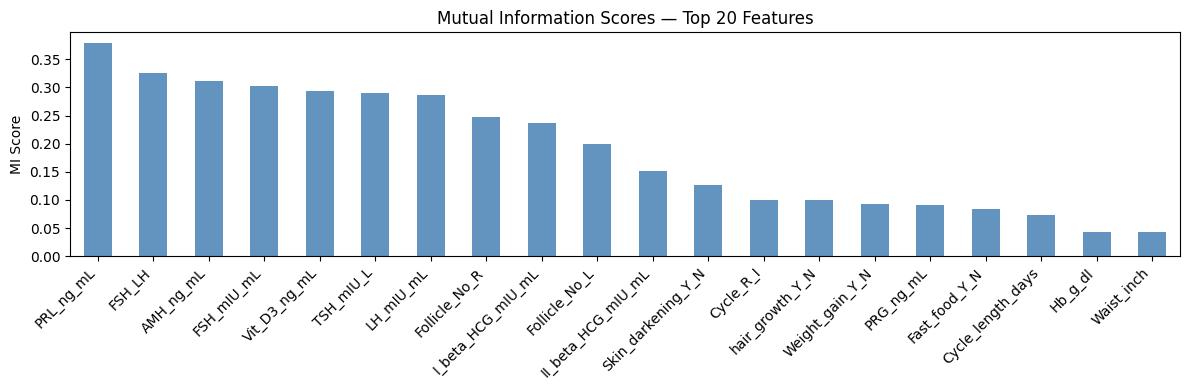

In [97]:
# ── Mutual Information feature selection ─────────────────────────────────────
# k=18 follows Patil & Jalnekar recommendation for this dataset.

mi_selector = SelectKBest(mutual_info_classif, k=18)
mi_selector.fit(X_train_full, y_train_full)
mi_mask     = mi_selector.get_support()
mi_features = X_train_full.columns[mi_mask].tolist()

print(f'MI selected {len(mi_features)} features:')
print(mi_features)

# Score bar chart
mi_scores = pd.Series(mi_selector.scores_, index=X_train_full.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 4))
mi_scores.head(20).plot(kind='bar', color='steelblue', alpha=0.85)
plt.title('Mutual Information Scores — Top 20 Features')
plt.ylabel('MI Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [98]:
# ── Boruta feature selection ──────────────────────────────────────────────────
# Boruta wraps a Random Forest and tests each feature against a shadow (permuted)
# copy. Features that consistently outperform their shadow are confirmed.

rf_boruta = RandomForestClassifier(n_jobs=-1, class_weight='balanced',
                                   max_depth=7, random_state=42)
boruta_sel = BorutaPy(rf_boruta, n_estimators='auto', max_iter=100,
                      random_state=42, verbose=0)
boruta_sel.fit(X_train_full.values, y_train_full.values)

boruta_mask     = boruta_sel.support_
boruta_features = X_train_full.columns[boruta_mask].tolist()
tentative_features = X_train_full.columns[boruta_sel.support_weak_].tolist()

print(f'Boruta confirmed {len(boruta_features)} features: {boruta_features}')
print(f'Boruta tentative {len(tentative_features)} features: {tentative_features}')


Boruta confirmed 38 features: ['Age_yrs', 'Weight_Kg', 'Height_Cm', 'BMI', 'Blood_Group', 'Pulse_rate_bpm', 'Hb_g_dl', 'Cycle_R_I', 'Cycle_length_days', 'Marraige_Status_Yrs', 'I_beta_HCG_mIU_mL', 'II_beta_HCG_mIU_mL', 'FSH_mIU_mL', 'LH_mIU_mL', 'FSH_LH', 'Hip_inch', 'Waist_inch', 'Waist_Hip_Ratio', 'TSH_mIU_L', 'AMH_ng_mL', 'PRL_ng_mL', 'Vit_D3_ng_mL', 'PRG_ng_mL', 'RBS_mg_dl', 'Weight_gain_Y_N', 'hair_growth_Y_N', 'Skin_darkening_Y_N', 'Hair_loss_Y_N', 'Pimples_Y_N', 'Fast_food_Y_N', 'Reg_Exercise_Y_N', 'BP_Systolic_mmHg', 'BP_Diastolic_mmHg', 'Follicle_No_L', 'Follicle_No_R', 'Avg_F_size_L_mm', 'Avg_F_size_R_mm', 'Endometrium_mm']
Boruta tentative 0 features: []


In [99]:
# ── Union of MI + Boruta, with multicollinearity removal ─────────────────────

union_raw = list(set(mi_features) | set(boruta_features))
print(f'Union size before multicollinearity check: {len(union_raw)}')

# Remove features correlated > 0.90 with another union feature (keep higher MI score)
X_union_raw  = X_train_full[union_raw]
corr_matrix  = X_union_raw.corr().abs()
upper_tri    = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop      = [col for col in upper_tri.columns if any(upper_tri[col] > 0.90)]
union_final  = [f for f in union_raw if f not in to_drop]

print(f'Union after removing {len(to_drop)} highly-correlated features: {len(union_final)}')
print(union_final)

# ── Create the four train/test array pairs ────────────────────────────────────
X_train_mi     = X_train_full[mi_features]
X_test_mi      = X_test[mi_features]

X_train_boruta = X_train_full[boruta_features]
X_test_boruta  = X_test[boruta_features]

X_train_union  = X_train_full[union_final]
X_test_union   = X_test[union_final]

# Venn overlap diagram
if _HAS_VENN:
    plt.figure(figsize=(6, 4))
    _venn2([set(mi_features), set(boruta_features)],
           set_labels=(f'MI ({len(mi_features)})', f'Boruta ({len(boruta_features)})'))
    plt.title('Feature Overlap: MI vs Boruta')
    plt.tight_layout()
    plt.show()
else:
    overlap = set(mi_features) & set(boruta_features)
    print(f'\nOverlapping features ({len(overlap)}): {sorted(overlap)}')

print('\nFeature sets ready:')
print(f'  All features:  {X_train_full.shape[1]}')
print(f'  MI:            {len(mi_features)}')
print(f'  Boruta:        {len(boruta_features)}')
print(f'  Union:         {len(union_final)}')


Union size before multicollinearity check: 38
Union after removing 1 highly-correlated features: 37
['Hb_g_dl', 'LH_mIU_mL', 'PRG_ng_mL', 'AMH_ng_mL', 'Weight_Kg', 'RBS_mg_dl', 'FSH_LH', 'Blood_Group', 'Follicle_No_L', 'Pimples_Y_N', 'Follicle_No_R', 'I_beta_HCG_mIU_mL', 'Hair_loss_Y_N', 'Height_Cm', 'II_beta_HCG_mIU_mL', 'Reg_Exercise_Y_N', 'BP_Systolic_mmHg', 'BMI', 'Marraige_Status_Yrs', 'TSH_mIU_L', 'Endometrium_mm', 'Waist_inch', 'Vit_D3_ng_mL', 'Pulse_rate_bpm', 'Hip_inch', 'Cycle_R_I', 'Weight_gain_Y_N', 'Cycle_length_days', 'Skin_darkening_Y_N', 'Avg_F_size_L_mm', 'PRL_ng_mL', 'hair_growth_Y_N', 'Fast_food_Y_N', 'BP_Diastolic_mmHg', 'Age_yrs', 'Waist_Hip_Ratio', 'Avg_F_size_R_mm']

Overlapping features (18): ['AMH_ng_mL', 'Cycle_R_I', 'Cycle_length_days', 'FSH_LH', 'FSH_mIU_mL', 'Fast_food_Y_N', 'Follicle_No_L', 'Follicle_No_R', 'II_beta_HCG_mIU_mL', 'I_beta_HCG_mIU_mL', 'LH_mIU_mL', 'PRG_ng_mL', 'PRL_ng_mL', 'Skin_darkening_Y_N', 'TSH_mIU_L', 'Vit_D3_ng_mL', 'Weight_gain_Y_N',

## 5b. SMOTE Variant Comparison

Standard SMOTE interpolates between minority neighbours, which can straddle the decision
boundary. Variants focus synthesis on more informative regions.

| Variant | Strategy | Literature |
|---|---|---|
| **Standard SMOTE** | Random minority interpolation | Baseline |
| **Borderline-SMOTE** | Only oversample near the boundary | Majumdar et al. 2024 |
| **KMeans-SMOTE** | Cluster minority first, then oversample within clusters | Majumdar et al. — RF 92.6% |

Evaluated on Random Forest with MI-selected features (5-Fold CV).


In [100]:
# ── SMOTE variant comparison ─────────────────────────────────────────────────
smote_variants = {
    'Standard SMOTE':   SMOTE(random_state=42),
    'Borderline SMOTE': BorderlineSMOTE(kind='borderline-1', random_state=42),
    'KMeans SMOTE':     KMeansSMOTE(random_state=42, cluster_balance_threshold=0.1),
}

smote_variant_rows = []
cv_smote = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for variant_name, smote_obj in smote_variants.items():
    pipe = ImbPipeline([
        ('smote', smote_obj),
        ('clf',   RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    scores = cross_validate(
        pipe, X_train_mi, y_train_full, cv=cv_smote,
        scoring={'accuracy': 'accuracy', 'recall': 'recall',
                 'f1': 'f1', 'roc_auc': 'roc_auc'},
        n_jobs=-1
    )
    smote_variant_rows.append({
        'SMOTE Variant':  variant_name,
        'CV Accuracy':    f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'CV Recall':      f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'CV F1':          f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'CV AUC':         f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        '_acc':           scores['test_accuracy'].mean(),
    })
    print(f'[Done] {variant_name}')

smote_var_df = (pd.DataFrame(smote_variant_rows)
                .sort_values('_acc', ascending=False)
                .drop(columns=['_acc'])
                .reset_index(drop=True))

print('\n=== SMOTE Variant Comparison (RF + MI features, 5-Fold CV) ===')
print(smote_var_df.to_string(index=False))

# Store best SMOTE variant for downstream use
_best_smote_name = smote_var_df.iloc[0]['SMOTE Variant']
BEST_SMOTE = smote_variants[_best_smote_name]
print(f'\nBest SMOTE variant: {_best_smote_name}')


[Done] Standard SMOTE
[Done] Borderline SMOTE
[Done] KMeans SMOTE

=== SMOTE Variant Comparison (RF + MI features, 5-Fold CV) ===
   SMOTE Variant     CV Accuracy       CV Recall           CV F1          CV AUC
Borderline SMOTE 0.9925 ± 0.0047 0.9917 ± 0.0041 0.9877 ± 0.0077 0.9998 ± 0.0002
  Standard SMOTE 0.9912 ± 0.0073 0.9917 ± 0.0041 0.9858 ± 0.0117 0.9997 ± 0.0002
    KMeans SMOTE 0.9893 ± 0.0038 0.9855 ± 0.0051 0.9825 ± 0.0062 0.9997 ± 0.0002

Best SMOTE variant: Borderline SMOTE


## 6. Defining Pipelines

Each pipeline uses `imblearn.pipeline.Pipeline` which integrates SMOTE correctly — SMOTE is applied
only to training folds during cross-validation, never to validation or test data.

Distance/kernel-sensitive models (SVM, KNN, Logistic Regression) include a `StandardScaler` step.
Tree-based models (Random Forest, Decision Tree, XGBoost) do not require scaling.

In [101]:
# Models that require StandardScaler: LR, SVM, KNN, NNN (MLP)
# Models that do NOT require scaling: RF, DT, NB, AdaBoost, GBM, XGB, LGBM, CatBoost
# SMOTE is always the first step so it only sees training data during each CV fold.

pipelines = {

    # ── Linear ──────────────────────────────────────────────────────────
    'Logistic Regression': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, random_state=42))
    ]),

    # ── Instance-based ──────────────────────────────────────────────────
    # FIX: KNN requires StandardScaler — Euclidean distance is dominated
    # by high-magnitude features (e.g. beta-HCG) without scaling.
    'KNN': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=5))
    ]),

    # ── Neural Network ──────────────────────────────────────────────────
    # Narrow Neural Network (NNN): a small MLP optimised for tabular data
    # at this scale (~400 training samples after SMOTE).
    # Architecture: two narrow hidden layers (64 → 32 neurons) with dropout
    # regularisation via alpha. Early stopping prevents overfitting.
    'Narrow Neural Network': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            solver='adam',
            alpha=0.01,              # L2 regularisation
            learning_rate='adaptive',
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=42
        ))
    ]),

    # ── Kernel-based ────────────────────────────────────────────────────
    # FIX: SVM previously trained on unscaled data → 53% accuracy.
    # With StandardScaler it is expected to reach 85–90%.
    'SVM': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', probability=True, random_state=42))
    ]),

    # ── Probabilistic ───────────────────────────────────────────────────
    'Naive Bayes': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   GaussianNB())
    ]),

    # ── Tree-based ──────────────────────────────────────────────────────
    'Decision Tree': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   DecisionTreeClassifier(random_state=42))
    ]),

    # ── Ensemble: Bagging ───────────────────────────────────────────────
    'Random Forest': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   RandomForestClassifier(n_estimators=100, random_state=42))
    ]),

    # ── Ensemble: Boosting ──────────────────────────────────────────────
    'AdaBoost': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3),
            n_estimators=100, learning_rate=0.1, random_state=42
        ))
    ]),

    'Gradient Boosting': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.1,
            max_depth=3, random_state=42
        ))
    ]),

    'XGBoost': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   XGBClassifier(
            n_estimators=100, use_label_encoder=False,
            eval_metric='logloss', random_state=42
        ))
    ]),

    'LightGBM': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   LGBMClassifier(
            n_estimators=100, learning_rate=0.1,
            num_leaves=31, random_state=42, verbose=-1
        ))
    ]),

    'CatBoost': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   CatBoostClassifier(
            iterations=100, learning_rate=0.1,
            depth=6, random_state=42, verbose=0
        ))
    ]),

    # ── Meta-ensemble: Stacking ─────────────────────────────────────────
    # Base learners: RF, XGBoost, LightGBM (diverse algorithms)
    # Meta-learner: Logistic Regression (interpretable; fits on held-out
    # fold predictions from base learners, not raw features)
    # Note: StackingClassifier cannot sit inside ImbPipeline directly
    # because its internal CV already handles fold splitting.
    # SMOTE is therefore applied manually in the stacking CV loop below.
    'Stacking': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', StackingClassifier(
            estimators=[
                ('rf',   RandomForestClassifier(n_estimators=100, random_state=42)),
                ('xgb',  XGBClassifier(n_estimators=100, use_label_encoder=False,
                                       eval_metric='logloss', random_state=42)),
                ('lgbm', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)),
            ],
            final_estimator=LogisticRegression(max_iter=1000),
            cv=5,
            n_jobs=-1
        ))
    ]),
}

print(f'{len(pipelines)} pipelines defined:')
for name in pipelines:
    print(f'  • {name}')

13 pipelines defined:
  • Logistic Regression
  • KNN
  • Narrow Neural Network
  • SVM
  • Naive Bayes
  • Decision Tree
  • Random Forest
  • AdaBoost
  • Gradient Boosting
  • XGBoost
  • LightGBM
  • CatBoost
  • Stacking


## 7. Stratified K-Fold Cross-Validation (Baseline)

Using 5-fold stratified cross-validation on the training set to compare baseline models.
Reporting both accuracy and PCOS-class recall — in medical diagnosis, false negatives
(missing a PCOS case) are clinically more costly than false positives.

In [102]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train_full, y_train_full,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'recall_pcos': 'recall',          # recall for class 1 (PCOS positive)
            'f1': 'f1',
            'roc_auc': 'roc_auc'
        },
        n_jobs=-1
    )
    
    cv_results.append({
        'Model': name,
        'Accuracy': f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'Recall (PCOS)': f"{scores['test_recall_pcos'].mean():.4f} ± {scores['test_recall_pcos'].std():.4f}",
        'F1': f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'AUC': f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        '_acc_mean': scores['test_accuracy'].mean(),
        '_recall_mean': scores['test_recall_pcos'].mean(),
    })
    print(f'[Done] {name}')

cv_df = pd.DataFrame(cv_results).sort_values('_acc_mean', ascending=False).reset_index(drop=True)
display_df = cv_df.drop(columns=['_acc_mean', '_recall_mean'])

print('\n=== Baseline CV Results (5-Fold Stratified) ===')
print(display_df.to_string(index=False))

[Done] Logistic Regression
[Done] KNN
[Done] Narrow Neural Network
[Done] SVM
[Done] Naive Bayes
[Done] Decision Tree
[Done] Random Forest
[Done] AdaBoost
[Done] Gradient Boosting
[Done] XGBoost
[Done] LightGBM
[Done] CatBoost
[Done] Stacking

=== Baseline CV Results (5-Fold Stratified) ===
                Model        Accuracy   Recall (PCOS)              F1             AUC
             CatBoost 0.9900 ± 0.0050 0.9855 ± 0.0051 0.9836 ± 0.0081 0.9987 ± 0.0011
             LightGBM 0.9894 ± 0.0067 0.9876 ± 0.0078 0.9826 ± 0.0109 0.9995 ± 0.0003
              XGBoost 0.9881 ± 0.0075 0.9897 ± 0.0065 0.9806 ± 0.0122 0.9988 ± 0.0015
             Stacking 0.9875 ± 0.0066 0.9876 ± 0.0078 0.9795 ± 0.0107 0.9996 ± 0.0003
        Random Forest 0.9868 ± 0.0070 0.9876 ± 0.0078 0.9786 ± 0.0114 0.9995 ± 0.0003
    Gradient Boosting 0.9800 ± 0.0073 0.9690 ± 0.0067 0.9671 ± 0.0119 0.9968 ± 0.0012
Narrow Neural Network 0.9768 ± 0.0140 0.9751 ± 0.0312 0.9621 ± 0.0231 0.9926 ± 0.0075
                  SV

## 7b. Feature Selection Experiment

Comparing four feature sets (all, MI, Boruta, union) across the top boosting models
with SMOTE inside CV. Directly replicates Patil & Jalnekar (2024) experimental design.


In [103]:
# ── Feature selection cross-validation comparison ─────────────────────────────
feature_sets = {
    'All features':             X_train_full,
    f'MI ({len(mi_features)})': X_train_mi,
    f'Boruta ({len(boruta_features)})': X_train_boruta,
    f'Union ({len(union_final)})':      X_train_union,
}

top_models_fs = {
    'LGBM':     LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'XGBoost':  XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42),
    'RF':       RandomForestClassifier(n_estimators=100, random_state=42),
    'CatBoost': CatBoostClassifier(iterations=100, random_state=42, verbose=0),
}

fs_rows = []
cv_fs = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fs_name, X_tr in feature_sets.items():
    for model_name, model_obj in top_models_fs.items():
        pipe = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('clf',   model_obj)
        ])
        scores = cross_validate(
            pipe, X_tr, y_train_full, cv=cv_fs,
            scoring={'accuracy': 'accuracy', 'recall': 'recall',
                     'f1': 'f1', 'roc_auc': 'roc_auc'},
            n_jobs=-1
        )
        fs_rows.append({
            'Feature Set': fs_name,
            'Model':       model_name,
            'CV Accuracy': f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
            'CV Recall':   f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
            'CV F1':       f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
            'CV AUC':      f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
            '_acc':        scores['test_accuracy'].mean(),
        })
        print(f'[Done] {fs_name:25} {model_name}')

fs_df = (pd.DataFrame(fs_rows)
         .sort_values(['Feature Set', '_acc'], ascending=[True, False])
         .drop(columns=['_acc'])
         .reset_index(drop=True))

print('\n=== Feature Selection Comparison (5-Fold CV) ===')
print(fs_df.to_string(index=False))

# Identify best feature set for stacking
_fs_raw = pd.DataFrame(fs_rows)
_best_fs_row = _fs_raw.sort_values('_acc', ascending=False).iloc[0]
BEST_FS_NAME  = _best_fs_row['Feature Set']
BEST_FS_TRAIN = feature_sets[BEST_FS_NAME]
print(f'\nBest feature set: {BEST_FS_NAME} ({_best_fs_row["Model"]})')


[Done] All features              LGBM
[Done] All features              XGBoost
[Done] All features              RF
[Done] All features              CatBoost
[Done] MI (18)                   LGBM
[Done] MI (18)                   XGBoost
[Done] MI (18)                   RF
[Done] MI (18)                   CatBoost
[Done] Boruta (38)               LGBM
[Done] Boruta (38)               XGBoost
[Done] Boruta (38)               RF
[Done] Boruta (38)               CatBoost
[Done] Union (37)                LGBM
[Done] Union (37)                XGBoost
[Done] Union (37)                RF
[Done] Union (37)                CatBoost

=== Feature Selection Comparison (5-Fold CV) ===
 Feature Set    Model     CV Accuracy       CV Recall           CV F1          CV AUC
All features CatBoost 0.9900 ± 0.0067 0.9835 ± 0.0051 0.9836 ± 0.0108 0.9995 ± 0.0004
All features     LGBM 0.9894 ± 0.0067 0.9876 ± 0.0078 0.9826 ± 0.0109 0.9995 ± 0.0003
All features  XGBoost 0.9881 ± 0.0075 0.9897 ± 0.0065 0.9806 ± 0

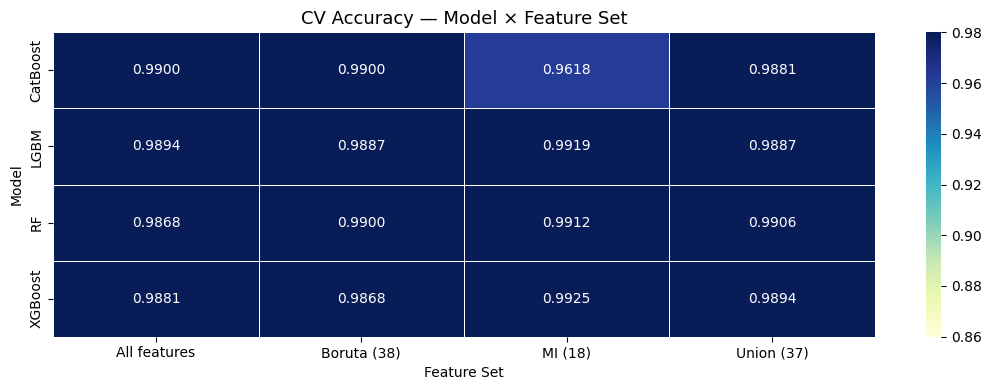

In [104]:
# ── Heatmap: accuracy by model × feature set ─────────────────────────────────
_pivot = (pd.DataFrame(fs_rows)
          .assign(Accuracy=lambda d: d['CV Accuracy'].str.split(' ± ').str[0].astype(float))
          .pivot(index='Model', columns='Feature Set', values='Accuracy'))

plt.figure(figsize=(11, 4))
sns.heatmap(_pivot, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, linecolor='white', vmin=0.86, vmax=0.98)
plt.title('CV Accuracy — Model × Feature Set', fontsize=13)
plt.tight_layout()
plt.show()


## 7c. Advanced Stacking Classifier

Multi-layer stacking using the best-performing feature set from Section 7b.
Literature benchmarks:
- Rahman et al. — SMOTE + Stacking: **98% accuracy**
- Patil & Jalnekar — MI-Stacking: **94.98% acc, AUC 0.9894**

**Architecture:**
- Level-0 base learners: RF + XGBoost + LightGBM + CatBoost
- Level-1 meta-learner: Logistic Regression (interpretable)
- SMOTE inside the outer CV loop — no leakage


In [105]:
# ── Stacking classifier cross-validation ─────────────────────────────────────
from sklearn.ensemble import StackingClassifier

stacking_clf = StackingClassifier(
    estimators=[
        ('rf',   RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
        ('xgb',  XGBClassifier(n_estimators=200, learning_rate=0.05,
                                eval_metric='logloss', random_state=42)),
        ('lgbm', LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                 num_leaves=31, random_state=42, verbose=-1)),
        ('cat',  CatBoostClassifier(iterations=200, learning_rate=0.05,
                                     depth=6, random_state=42, verbose=0)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0),
    cv=5, n_jobs=-1, passthrough=False
)

stacking_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   stacking_clf)
])

cv_stack = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stack_scores = cross_validate(
    stacking_pipe,
    BEST_FS_TRAIN, y_train_full,
    cv=cv_stack,
    scoring={'accuracy': 'accuracy', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'},
    n_jobs=1   # stacking is already internally parallel
)

print(f'=== Stacking Classifier CV Results (feature set: {BEST_FS_NAME}) ===')
print(f"Accuracy:      {stack_scores['test_accuracy'].mean():.4f} ± {stack_scores['test_accuracy'].std():.4f}")
print(f"Recall (PCOS): {stack_scores['test_recall'].mean():.4f} ± {stack_scores['test_recall'].std():.4f}")
print(f"F1:            {stack_scores['test_f1'].mean():.4f} ± {stack_scores['test_f1'].std():.4f}")
print(f"AUC:           {stack_scores['test_roc_auc'].mean():.4f} ± {stack_scores['test_roc_auc'].std():.4f}")


=== Stacking Classifier CV Results (feature set: MI (18)) ===
Accuracy:      0.9919 ± 0.0051
Recall (PCOS): 0.9876 ± 0.0041
F1:            0.9866 ± 0.0083
AUC:           0.9997 ± 0.0002


=== Stacking — Final Test Set (MI (18)) ===
Accuracy:      0.9900
Recall (PCOS): 0.9917
F1:            0.9836
AUC:           0.9996

              precision    recall  f1-score   support

     No PCOS       1.00      0.99      0.99       279
        PCOS       0.98      0.99      0.98       121

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



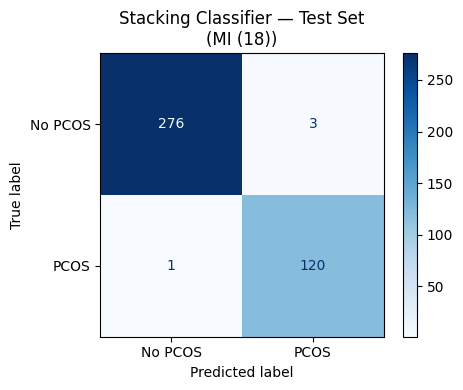

In [106]:
# ── Final hold-out test set evaluation of stacking model ──────────────────────
# Determine which test set to use based on best feature set name
_fs_test_map = {
    'All features':             X_test,
    f'MI ({len(mi_features)})': X_test_mi,
    f'Boruta ({len(boruta_features)})': X_test_boruta,
    f'Union ({len(union_final)})':      X_test_union,
}
X_test_best_fs = _fs_test_map.get(BEST_FS_NAME, X_test)

stacking_pipe.fit(BEST_FS_TRAIN, y_train_full)
y_pred_stack  = stacking_pipe.predict(X_test_best_fs)
y_proba_stack = stacking_pipe.predict_proba(X_test_best_fs)[:, 1]

print(f'=== Stacking — Final Test Set ({BEST_FS_NAME}) ===')
print(f'Accuracy:      {accuracy_score(y_test, y_pred_stack):.4f}')
print(f'Recall (PCOS): {recall_score(y_test, y_pred_stack):.4f}')
print(f'F1:            {f1_score(y_test, y_pred_stack):.4f}')
print(f'AUC:           {roc_auc_score(y_test, y_proba_stack):.4f}')
print()
print(classification_report(y_test, y_pred_stack, target_names=['No PCOS', 'PCOS']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_stack,
    display_labels=['No PCOS', 'PCOS'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Stacking Classifier — Test Set\n({BEST_FS_NAME})')
plt.tight_layout()
plt.show()


## 8. Hyperparameter Tuning (GridSearchCV)

Tuning the top-performing models using `GridSearchCV` nested inside the imblearn pipeline.
SMOTE remains inside the pipeline so it is never applied to validation folds.

In [107]:
# Hyperparameter grids — pipeline param names use the step name as prefix.
# e.g. clf__n_estimators refers to the 'clf' step's n_estimators parameter.
# Scoring is set to 'recall' to optimise for PCOS sensitivity (fewer missed cases).

tuning_configs = {

    # ── KNN: tune number of neighbours and distance weighting ───────────
    'KNN': {
        'pipeline': ImbPipeline([
            ('smote',  SMOTE(random_state=42)),
            ('scaler', StandardScaler()),
            ('clf',    KNeighborsClassifier())
        ]),
        'params': {
            'clf__n_neighbors': [3, 5, 7, 9, 11, 15],
            'clf__weights':     ['uniform', 'distance'],
            'clf__metric':      ['euclidean', 'manhattan'],
        },
        'search': 'grid'
    },

    # ── NNN (Narrow Neural Network): tune hidden layer width and regularisation
    # Narrow architectures (few neurons per layer) are appropriate for small
    # datasets (~400 training samples) — wide layers overfit.
    # early_stopping avoids the need for explicit epoch tuning.
    'Narrow Neural Network': {
        'pipeline': ImbPipeline([
            ('smote',  SMOTE(random_state=42)),
            ('scaler', StandardScaler()),
            ('clf',    MLPClassifier(
                solver='adam', max_iter=500,
                early_stopping=True, validation_fraction=0.1,
                n_iter_no_change=20, random_state=42
            ))
        ]),
        'params': {
            'clf__hidden_layer_sizes': [
                (32,),          # single narrow layer
                (64,),          # single wider layer
                (64, 32),       # two-layer — original NNN shape
                (128, 64),      # wider two-layer
                (64, 32, 16),   # three-layer (deeper)
            ],
            'clf__activation': ['relu', 'tanh'],
            'clf__alpha':      [0.0001, 0.001, 0.01, 0.1],   # L2 regularisation
            'clf__learning_rate': ['constant', 'adaptive'],
        },
        'search': 'random',   # large grid — use RandomizedSearchCV
        'n_iter': 30
    },

    # ── SVM: tune C, kernel, gamma ──────────────────────────────────────
    'SVM': {
        'pipeline': ImbPipeline([
            ('smote',  SMOTE(random_state=42)),
            ('scaler', StandardScaler()),
            ('clf',    SVC(probability=True, random_state=42))
        ]),
        'params': {
            'clf__C':      [0.1, 1.0, 10.0, 100.0],
            'clf__kernel': ['rbf', 'linear', 'poly'],
            'clf__gamma':  ['scale', 'auto'],
        },
        'search': 'grid'
    },

    # ── Logistic Regression ─────────────────────────────────────────────
    'Logistic Regression': {
        'pipeline': ImbPipeline([
            ('smote',  SMOTE(random_state=42)),
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'params': {
            'clf__C':       [0.01, 0.1, 1.0, 10.0, 100.0],
            'clf__penalty': ['l1', 'l2'],
            'clf__solver':  ['liblinear'],
        },
        'search': 'grid'
    },

    # ── Random Forest ───────────────────────────────────────────────────
    'Random Forest': {
        'pipeline': ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('clf',   RandomForestClassifier(random_state=42))
        ]),
        'params': {
            'clf__n_estimators':    [100, 200, 300],
            'clf__max_depth':       [None, 10, 20],
            'clf__min_samples_split': [2, 5, 10],
            'clf__max_features':    ['sqrt', 'log2'],
        },
        'search': 'random',
        'n_iter': 20
    },

    # ── XGBoost ─────────────────────────────────────────────────────────
    'XGBoost': {
        'pipeline': ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('clf',   XGBClassifier(
                use_label_encoder=False, eval_metric='logloss', random_state=42
            ))
        ]),
        'params': {
            'clf__n_estimators':  [100, 200, 300],
            'clf__max_depth':     [3, 5, 7],
            'clf__learning_rate': [0.05, 0.1, 0.2],
            'clf__subsample':     [0.8, 1.0],
            'clf__colsample_bytree': [0.8, 1.0],
        },
        'search': 'random',
        'n_iter': 20
    },

    # ── LightGBM ────────────────────────────────────────────────────────
    'LightGBM': {
        'pipeline': ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('clf',   LGBMClassifier(random_state=42, verbose=-1))
        ]),
        'params': {
            'clf__n_estimators':  [100, 200, 300],
            'clf__num_leaves':    [15, 31, 63],
            'clf__learning_rate': [0.05, 0.1, 0.2],
            'clf__min_child_samples': [10, 20, 30],
        },
        'search': 'random',
        'n_iter': 20
    },

    # ── CatBoost ────────────────────────────────────────────────────────
    'CatBoost': {
        'pipeline': ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('clf',   CatBoostClassifier(random_state=42, verbose=0))
        ]),
        'params': {
            'clf__iterations':    [100, 200, 300],
            'clf__depth':         [4, 6, 8],
            'clf__learning_rate': [0.05, 0.1, 0.2],
            'clf__l2_leaf_reg':   [1, 3, 5, 7],
        },
        'search': 'random',
        'n_iter': 20
    },
}

tuned_results = []
best_estimators = {}

for name, cfg in tuning_configs.items():
    print(f'Tuning {name}...')

    common_kwargs = dict(
        estimator=cfg['pipeline'],
        param_grid=cfg['params'] if cfg['search'] == 'grid' else None,
        param_distributions=cfg['params'] if cfg['search'] == 'random' else None,
        cv=cv,
        scoring='recall',
        n_jobs=-1,
        verbose=0
    )

    if cfg['search'] == 'grid':
        searcher = GridSearchCV(
            estimator=cfg['pipeline'],
            param_grid=cfg['params'],
            cv=cv, scoring='recall', n_jobs=-1, verbose=0
        )
    else:
        searcher = RandomizedSearchCV(
            estimator=cfg['pipeline'],
            param_distributions=cfg['params'],
            n_iter=cfg.get('n_iter', 20),
            cv=cv, scoring='recall', n_jobs=-1,
            random_state=42, verbose=0
        )

    searcher.fit(X_train_full, y_train_full)
    best_estimators[name] = searcher.best_estimator_

    y_pred = searcher.predict(X_test)
    y_prob = searcher.predict_proba(X_test)[:, 1] if hasattr(searcher, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    tuned_results.append({
        'Model':              name,
        'Search':             cfg['search'].capitalize(),
        'Best Params':        str(searcher.best_params_),
        'Test Accuracy':      round(acc, 4),
        'Test Recall (PCOS)': round(rec, 4),
        'Test F1':            round(f1, 4),
        'Test AUC':           round(auc, 4) if auc else 'N/A',
        '_acc': acc
    })
    print(f'  Best CV recall: {searcher.best_score_:.4f} | Test acc: {acc:.4f} | Test recall: {rec:.4f}')
    print(f'  Best params: {searcher.best_params_}\n')

tuned_df = (
    pd.DataFrame(tuned_results)
    .sort_values('_acc', ascending=False)
    .reset_index(drop=True)
)

print('\n=== Tuned Model Results on Hold-Out Test Set ===')
print(tuned_df.drop(columns=['_acc', 'Best Params', 'Search']).to_string(index=False))

Tuning KNN...
  Best CV recall: 0.9855 | Test acc: 0.9875 | Test recall: 0.9669
  Best params: {'clf__metric': 'manhattan', 'clf__n_neighbors': 15, 'clf__weights': 'distance'}

Tuning Narrow Neural Network...
  Best CV recall: 0.9793 | Test acc: 0.9825 | Test recall: 0.9752
  Best params: {'clf__learning_rate': 'constant', 'clf__hidden_layer_sizes': (64, 32, 16), 'clf__alpha': 0.001, 'clf__activation': 'relu'}

Tuning SVM...
  Best CV recall: 0.9876 | Test acc: 0.9825 | Test recall: 0.9669
  Best params: {'clf__C': 10.0, 'clf__gamma': 'scale', 'clf__kernel': 'poly'}

Tuning Logistic Regression...
  Best CV recall: 0.8905 | Test acc: 0.9150 | Test recall: 0.8595
  Best params: {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}

Tuning Random Forest...
  Best CV recall: 0.9917 | Test acc: 0.9925 | Test recall: 0.9752
  Best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}

Tuning XGBoost...
  Best CV recall:


=== KNN ===
              precision    recall  f1-score   support

     No PCOS       0.99      1.00      0.99       279
        PCOS       0.99      0.97      0.98       121

    accuracy                           0.99       400
   macro avg       0.99      0.98      0.99       400
weighted avg       0.99      0.99      0.99       400



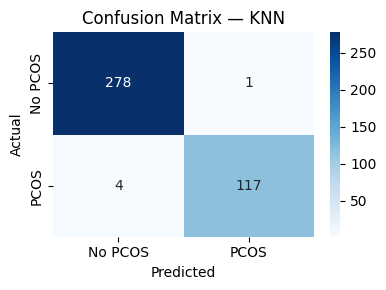


=== Narrow Neural Network ===
              precision    recall  f1-score   support

     No PCOS       0.99      0.99      0.99       279
        PCOS       0.97      0.98      0.97       121

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



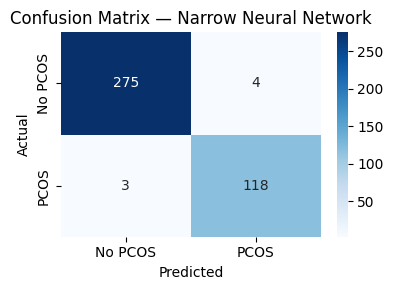


=== SVM ===
              precision    recall  f1-score   support

     No PCOS       0.99      0.99      0.99       279
        PCOS       0.97      0.97      0.97       121

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



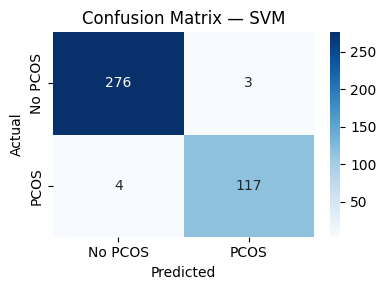


=== Logistic Regression ===
              precision    recall  f1-score   support

     No PCOS       0.94      0.94      0.94       279
        PCOS       0.86      0.86      0.86       121

    accuracy                           0.92       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.92      0.92      0.92       400



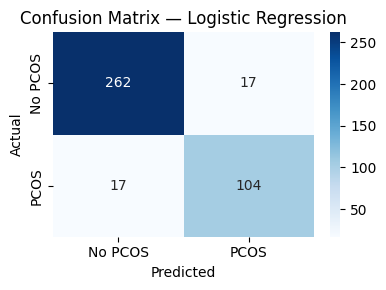


=== Random Forest ===
              precision    recall  f1-score   support

     No PCOS       0.99      1.00      0.99       279
        PCOS       1.00      0.98      0.99       121

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



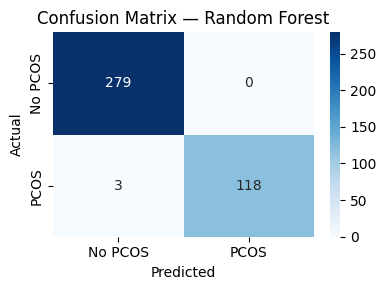


=== XGBoost ===
              precision    recall  f1-score   support

     No PCOS       1.00      1.00      1.00       279
        PCOS       0.99      0.99      0.99       121

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



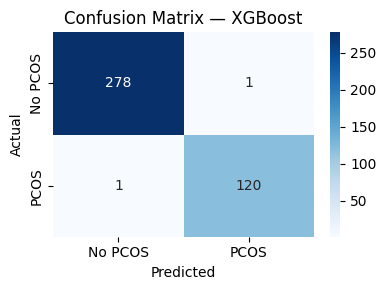


=== LightGBM ===
              precision    recall  f1-score   support

     No PCOS       1.00      0.99      0.99       279
        PCOS       0.98      0.99      0.99       121

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



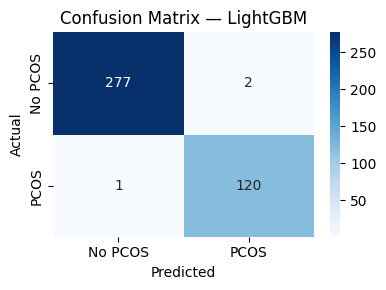


=== CatBoost ===
              precision    recall  f1-score   support

     No PCOS       1.00      1.00      1.00       279
        PCOS       0.99      0.99      0.99       121

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



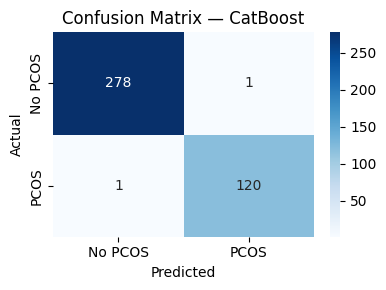

In [108]:
# Full classification reports for each tuned model
for name, est in best_estimators.items():
    y_pred = est.predict(X_test)
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['No PCOS', 'PCOS']))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No PCOS', 'PCOS'],
                yticklabels=['No PCOS', 'PCOS'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()

## 9. Experiment Variants

Each experiment applies a different combination of techniques to all 12 models.
All share the same corrected pipeline: SMOTE inside the fold, scalers where required,
PCA fitted on training data only.

| # | Label | SMOTE | Scaler | PCA | Hypertuning |
|---|---|:---:|:---:|:---:|:---:|
| E1 | Baseline | ✗ | ✗ | ✗ | ✗ |
| E2 | SMOTE only | ✓ | ✗ | ✗ | ✗ |
| E3 | PCA only | ✗ | ✓ | ✓ | ✗ |
| E4 | Hypertuning only | ✗ | ✗ | ✗ | ✓ |
| E5 | SMOTE + PCA | ✓ | ✓ | ✓ | ✗ |
| E6 | SMOTE + Hypertuning | ✓ | ✗ | ✗ | ✓ |
| E7 | SMOTE + PCA + Hypertuning | ✓ | ✓ | ✓ | ✓ |

All results aggregate into a master heatmap and ranking table in Section 10.

In [109]:
# ── Experiment infrastructure ─────────────────────────────────────────────────
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.base import clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import numpy as np
import warnings
warnings.filterwarnings('ignore')

N_PCA = 10
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'recall': 'recall',
           'f1': 'f1', 'roc_auc': 'roc_auc'}

MODEL_REGISTRY = [
    ('LR',   LogisticRegression(max_iter=1000, random_state=42),                            True),
    ('KNN',  KNeighborsClassifier(n_neighbors=5),                                           True),
    ('NNN',  MLPClassifier(hidden_layer_sizes=(64,32), alpha=0.01, max_iter=500,
                           early_stopping=True, random_state=42),                           True),
    ('SVM',  SVC(kernel='rbf', probability=True, random_state=42),                         True),
    ('NB',   GaussianNB(),                                                                  False),
    ('DT',   DecisionTreeClassifier(random_state=42),                                       False),
    ('RF',   RandomForestClassifier(n_estimators=100, random_state=42),                     False),
    ('ADA',  AdaBoostClassifier(n_estimators=100, random_state=42),                         False),
    ('GBM',  GradientBoostingClassifier(n_estimators=100, random_state=42),                 False),
    ('XGB',  XGBClassifier(n_estimators=100, use_label_encoder=False,
                           eval_metric='logloss', random_state=42, verbosity=0),            False),
    ('LGBM', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),                False),
    ('CAT',  CatBoostClassifier(iterations=100, random_state=42, verbose=0),                False),
]

PARAM_GRIDS = {
    'LR':   {'clf__C': [0.01,0.1,1,10,100], 'clf__penalty': ['l1','l2'],
              'clf__solver': ['liblinear']},
    'KNN':  {'clf__n_neighbors': [3,5,7,9,11,15], 'clf__weights': ['uniform','distance'],
              'clf__metric': ['euclidean','manhattan']},
    'NNN':  {'clf__hidden_layer_sizes': [(32,),(64,),(64,32),(128,64),(64,32,16)],
              'clf__activation': ['relu','tanh'], 'clf__alpha': [0.0001,0.001,0.01,0.1],
              'clf__learning_rate': ['constant','adaptive']},
    'SVM':  {'clf__C': [0.1,1,10,100], 'clf__kernel': ['rbf','linear'],
              'clf__gamma': ['scale','auto']},
    'NB':   {},
    'DT':   {'clf__max_depth': [None,5,10,20], 'clf__min_samples_split': [2,5,10]},
    'RF':   {'clf__n_estimators': [100,200,300], 'clf__max_depth': [None,10,20],
              'clf__min_samples_split': [2,5], 'clf__max_features': ['sqrt','log2']},
    'ADA':  {'clf__n_estimators': [50,100,200], 'clf__learning_rate': [0.01,0.1,1.0]},
    'GBM':  {'clf__n_estimators': [100,200], 'clf__learning_rate': [0.05,0.1,0.2],
              'clf__max_depth': [3,5]},
    'XGB':  {'clf__n_estimators': [100,200], 'clf__max_depth': [3,5,7],
              'clf__learning_rate': [0.05,0.1,0.2], 'clf__subsample': [0.8,1.0]},
    'LGBM': {'clf__n_estimators': [100,200], 'clf__num_leaves': [15,31,63],
              'clf__learning_rate': [0.05,0.1,0.2]},
    'CAT':  {'clf__iterations': [100,200], 'clf__depth': [4,6,8],
              'clf__learning_rate': [0.05,0.1,0.2]},
}
RANDOM_SEARCH_MODELS = {'NNN', 'RF', 'XGB', 'LGBM', 'CAT', 'ADA', 'GBM'}


def build_pipeline(clf, needs_scale, use_smote=False, use_pca=False):
    steps = []
    if use_smote:
        steps.append(('smote', SMOTE(random_state=42)))
    if needs_scale or use_pca:
        steps.append(('scaler', StandardScaler()))
    if use_pca:
        steps.append(('pca', PCA(n_components=N_PCA)))
    steps.append(('clf', clf))
    return ImbPipeline(steps)


def run_experiment(label, use_smote, use_pca, use_hypertune,
                   X_tr, y_tr, n_iter=15):
    rows = []
    for ml, clf_tmpl, needs_scale in MODEL_REGISTRY:
        clf  = clone(clf_tmpl)
        grid = PARAM_GRIDS.get(ml, {})
        pipe = build_pipeline(clf, needs_scale, use_smote, use_pca)

        if use_hypertune and grid:
            if ml in RANDOM_SEARCH_MODELS:
                srch = RandomizedSearchCV(pipe, grid, n_iter=n_iter, cv=cv,
                                          scoring='recall', n_jobs=-1,
                                          random_state=42, verbose=0)
            else:
                srch = GridSearchCV(pipe, grid, cv=cv, scoring='recall',
                                    n_jobs=-1, verbose=0)
            srch.fit(X_tr, y_tr)
            pipe = srch.best_estimator_

        s = cross_validate(pipe, X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1)
        row = {
            'Experiment':  label,
            'Model':       ml,
            'Accuracy':    round(s['test_accuracy'].mean(), 4),
            'Acc_std':     round(s['test_accuracy'].std(),  4),
            'Recall':      round(s['test_recall'].mean(),   4),
            'Rec_std':     round(s['test_recall'].std(),    4),
            'F1':          round(s['test_f1'].mean(),       4),
            'F1_std':      round(s['test_f1'].std(),        4),
            'AUC':         round(s['test_roc_auc'].mean(),  4),
            'AUC_std':     round(s['test_roc_auc'].std(),   4),
        }
        rows.append(row)
        print(f'  [{label}] {ml:6} acc={row["Accuracy"]:.4f}  rec={row["Recall"]:.4f}')
    return rows


print('Infrastructure ready.')
print(f'Models ({len(MODEL_REGISTRY)}): {[m[0] for m in MODEL_REGISTRY]}')


Infrastructure ready.
Models (12): ['LR', 'KNN', 'NNN', 'SVM', 'NB', 'DT', 'RF', 'ADA', 'GBM', 'XGB', 'LGBM', 'CAT']


### E1 — Baseline (no SMOTE · no PCA · no tuning)

Performance floor — raw models on the imbalanced dataset. All other experiments
should improve recall over this. Expected weakness: low sensitivity on PCOS class.

In [110]:
print('Running E1 — Baseline...')
e1_results = run_experiment('E1: Baseline', False, False, False,
                             X_train_full, y_train_full)
e1_df = pd.DataFrame(e1_results)
print('\nE1 done.')
print(e1_df[['Model','Accuracy','Recall','F1','AUC']].to_string(index=False))


Running E1 — Baseline...
  [E1: Baseline] LR     acc=0.9205  rec=0.8347
  [E1: Baseline] KNN    acc=0.9192  rec=0.8036
  [E1: Baseline] NNN    acc=0.9543  rec=0.8987
  [E1: Baseline] SVM    acc=0.9725  rec=0.9195
  [E1: Baseline] NB     acc=0.8773  rec=0.8203
  [E1: Baseline] DT     acc=0.9756  rec=0.9628
  [E1: Baseline] RF     acc=0.9925  rec=0.9876
  [E1: Baseline] ADA    acc=0.9499  rec=0.8925
  [E1: Baseline] GBM    acc=0.9881  rec=0.9752
  [E1: Baseline] XGB    acc=0.9868  rec=0.9835
  [E1: Baseline] LGBM   acc=0.9906  rec=0.9896
  [E1: Baseline] CAT    acc=0.9875  rec=0.9752

E1 done.
Model  Accuracy  Recall     F1    AUC
   LR    0.9205  0.8347 0.8638 0.9584
  KNN    0.9192  0.8036 0.8572 0.9812
  NNN    0.9543  0.8987 0.9222 0.9870
  SVM    0.9725  0.9195 0.9527 0.9931
   NB    0.8773  0.8203 0.8001 0.9306
   DT    0.9756  0.9628 0.9598 0.9719
   RF    0.9925  0.9876 0.9877 0.9998
  ADA    0.9499  0.8925 0.9150 0.9890
  GBM    0.9881  0.9752 0.9803 0.9980
  XGB    0.9868  0.98

### E2 — SMOTE only

SMOTE applied inside each training fold to balance classes (363 vs 363).
No scaling (tree-based models don't need it), no PCA, no hypertuning.
Expected: large recall improvement over E1 for all models.

In [111]:
print('Running E2 — SMOTE only...')
e2_results = run_experiment('E2: SMOTE', True, False, False,
                             X_train_full, y_train_full)
e2_df = pd.DataFrame(e2_results)
print('\nE2 done.')
print(e2_df[['Model','Accuracy','Recall','F1','AUC']].to_string(index=False))


Running E2 — SMOTE only...
  [E2: SMOTE] LR     acc=0.8804  rec=0.8781
  [E2: SMOTE] KNN    acc=0.9349  rec=0.9585
  [E2: SMOTE] NNN    acc=0.9549  rec=0.9358
  [E2: SMOTE] SVM    acc=0.9731  rec=0.9566
  [E2: SMOTE] NB     acc=0.8516  rec=0.8637
  [E2: SMOTE] DT     acc=0.9699  rec=0.9669
  [E2: SMOTE] RF     acc=0.9868  rec=0.9876
  [E2: SMOTE] ADA    acc=0.9280  rec=0.9069
  [E2: SMOTE] GBM    acc=0.9800  rec=0.9690
  [E2: SMOTE] XGB    acc=0.9881  rec=0.9897
  [E2: SMOTE] LGBM   acc=0.9894  rec=0.9876
  [E2: SMOTE] CAT    acc=0.9900  rec=0.9835

E2 done.
Model  Accuracy  Recall     F1    AUC
   LR    0.8804  0.8781 0.8164 0.9539
  KNN    0.9349  0.9585 0.8990 0.9860
  NNN    0.9549  0.9358 0.9259 0.9896
  SVM    0.9731  0.9566 0.9556 0.9976
   NB    0.8516  0.8637 0.7794 0.9241
   DT    0.9699  0.9669 0.9514 0.9691
   RF    0.9868  0.9876 0.9786 0.9995
  ADA    0.9280  0.9069 0.8843 0.9828
  GBM    0.9800  0.9690 0.9671 0.9968
  XGB    0.9881  0.9897 0.9806 0.9988
 LGBM    0.9894  

### E3 — PCA only (no SMOTE · no tuning)

StandardScaler + PCA (10 components) on the imbalanced dataset.
PCA is fit on training folds only. Hypothesis: performance drops vs E1 because
PCOS features have diffuse variance (~10% per component) — no dominant direction to compress.

In [112]:
print('Running E3 — PCA only...')
e3_results = run_experiment('E3: PCA', False, True, False,
                             X_train_full, y_train_full)
e3_df = pd.DataFrame(e3_results)
print('\nE3 done.')
print(e3_df[['Model','Accuracy','Recall','F1','AUC']].to_string(index=False))


Running E3 — PCA only...
  [E3: PCA] LR     acc=0.9011  rec=0.8017
  [E3: PCA] KNN    acc=0.9330  rec=0.8698
  [E3: PCA] NNN    acc=0.9111  rec=0.7997
  [E3: PCA] SVM    acc=0.9299  rec=0.8243
  [E3: PCA] NB     acc=0.8635  rec=0.7335
  [E3: PCA] DT     acc=0.9480  rec=0.9277
  [E3: PCA] RF     acc=0.9743  rec=0.9442
  [E3: PCA] ADA    acc=0.8904  rec=0.7561
  [E3: PCA] GBM    acc=0.9493  rec=0.8884
  [E3: PCA] XGB    acc=0.9724  rec=0.9401
  [E3: PCA] LGBM   acc=0.9806  rec=0.9587
  [E3: PCA] CAT    acc=0.9449  rec=0.8719

E3 done.
Model  Accuracy  Recall     F1    AUC
   LR    0.9011  0.8017 0.8311 0.9505
  KNN    0.9330  0.8698 0.8875 0.9813
  NNN    0.9111  0.7997 0.8435 0.9368
  SVM    0.9299  0.8243 0.8762 0.9692
   NB    0.8635  0.7335 0.7648 0.9211
   DT    0.9480  0.9277 0.9154 0.9423
   RF    0.9743  0.9442 0.9570 0.9963
  ADA    0.8904  0.7561 0.8055 0.9591
  GBM    0.9493  0.8884 0.9140 0.9841
  XGB    0.9724  0.9401 0.9538 0.9930
 LGBM    0.9806  0.9587 0.9677 0.9953
  CAT

### E4 — Hyperparameter tuning only (no SMOTE · no PCA)

GridSearchCV / RandomizedSearchCV on the raw imbalanced dataset.
Tuning target is recall. Isolates hypertuning's contribution from class balancing.
Expected: modest accuracy gains, limited recall improvement vs E1 (imbalance uncorrected).

In [113]:
print('Running E4 — Hypertuning only...')
e4_results = run_experiment('E4: Hypertune', False, False, True,
                             X_train_full, y_train_full)
e4_df = pd.DataFrame(e4_results)
print('\nE4 done.')
print(e4_df[['Model','Accuracy','Recall','F1','AUC']].to_string(index=False))


Running E4 — Hypertuning only...
  [E4: Hypertune] LR     acc=0.9098  rec=0.8471
  [E4: Hypertune] KNN    acc=0.9856  rec=0.9772
  [E4: Hypertune] NNN    acc=0.9662  rec=0.9278
  [E4: Hypertune] SVM    acc=0.9912  rec=0.9896
  [E4: Hypertune] NB     acc=0.8773  rec=0.8203
  [E4: Hypertune] DT     acc=0.9756  rec=0.9628
  [E4: Hypertune] RF     acc=0.9925  rec=0.9876
  [E4: Hypertune] ADA    acc=0.9649  rec=0.9359
  [E4: Hypertune] GBM    acc=0.9912  rec=0.9855
  [E4: Hypertune] XGB    acc=0.9900  rec=0.9855
  [E4: Hypertune] LGBM   acc=0.9906  rec=0.9896
  [E4: Hypertune] CAT    acc=0.9906  rec=0.9876

E4 done.
Model  Accuracy  Recall     F1    AUC
   LR    0.9098  0.8471 0.8507 0.9606
  KNN    0.9856  0.9772 0.9762 0.9904
  NNN    0.9662  0.9278 0.9424 0.9872
  SVM    0.9912  0.9896 0.9856 0.9996
   NB    0.8773  0.8203 0.8001 0.9306
   DT    0.9756  0.9628 0.9598 0.9719
   RF    0.9925  0.9876 0.9877 0.9998
  ADA    0.9649  0.9359 0.9415 0.9940
  GBM    0.9912  0.9855 0.9856 0.9990
 

### E5 — SMOTE + PCA (no hypertuning)

SMOTE first (inside fold), then StandardScaler + PCA on the balanced data.
Compares with E2 to isolate PCA's effect when added on top of SMOTE.
If E5 < E2 on recall, PCA is genuinely harmful on this dataset.

In [114]:
print('Running E5 — SMOTE + PCA...')
e5_results = run_experiment('E5: SMOTE+PCA', True, True, False,
                             X_train_full, y_train_full)
e5_df = pd.DataFrame(e5_results)
print('\nE5 done.')
print(e5_df[['Model','Accuracy','Recall','F1','AUC']].to_string(index=False))


Running E5 — SMOTE + PCA...
  [E5: SMOTE+PCA] LR     acc=0.8810  rec=0.8884
  [E5: SMOTE+PCA] KNN    acc=0.9424  rec=0.9565
  [E5: SMOTE+PCA] NNN    acc=0.8892  rec=0.8946
  [E5: SMOTE+PCA] SVM    acc=0.9186  rec=0.9173
  [E5: SMOTE+PCA] NB     acc=0.8052  rec=0.9113
  [E5: SMOTE+PCA] DT     acc=0.9292  rec=0.9276
  [E5: SMOTE+PCA] RF     acc=0.9743  rec=0.9731
  [E5: SMOTE+PCA] ADA    acc=0.8704  rec=0.8740
  [E5: SMOTE+PCA] GBM    acc=0.9230  rec=0.9256
  [E5: SMOTE+PCA] XGB    acc=0.9743  rec=0.9731
  [E5: SMOTE+PCA] LGBM   acc=0.9737  rec=0.9731
  [E5: SMOTE+PCA] CAT    acc=0.9374  rec=0.9421

E5 done.
Model  Accuracy  Recall     F1    AUC
   LR    0.8810  0.8884 0.8194 0.9474
  KNN    0.9424  0.9565 0.9099 0.9843
  NNN    0.8892  0.8946 0.8308 0.9560
  SVM    0.9186  0.9173 0.8731 0.9725
   NB    0.8052  0.9113 0.7412 0.9287
   DT    0.9292  0.9276 0.8890 0.9288
   RF    0.9743  0.9731 0.9582 0.9959
  ADA    0.8704  0.8740 0.8038 0.9523
  GBM    0.9230  0.9256 0.8798 0.9811
  XGB 

### E6 — SMOTE + Hyperparameter tuning (no PCA)

Expected strongest performer. SMOTE corrects imbalance, hypertuning finds
optimal parameters on the balanced dataset. Mirrors the best setups in the literature.
Tuning target: recall — minimise missed PCOS cases.

In [115]:
print('Running E6 — SMOTE + Hypertuning...')
e6_results = run_experiment('E6: SMOTE+Hypertune', True, False, True,
                             X_train_full, y_train_full)
e6_df = pd.DataFrame(e6_results)
print('\nE6 done.')
print(e6_df[['Model','Accuracy','Recall','F1','AUC']].to_string(index=False))


Running E6 — SMOTE + Hypertuning...
  [E6: SMOTE+Hypertune] LR     acc=0.8904  rec=0.8905
  [E6: SMOTE+Hypertune] KNN    acc=0.9887  rec=0.9855
  [E6: SMOTE+Hypertune] NNN    acc=0.9862  rec=0.9773
  [E6: SMOTE+Hypertune] SVM    acc=0.9875  rec=0.9835
  [E6: SMOTE+Hypertune] NB     acc=0.8516  rec=0.8637
  [E6: SMOTE+Hypertune] DT     acc=0.9699  rec=0.9669
  [E6: SMOTE+Hypertune] RF     acc=0.9887  rec=0.9917
  [E6: SMOTE+Hypertune] ADA    acc=0.9568  rec=0.9566
  [E6: SMOTE+Hypertune] GBM    acc=0.9862  rec=0.9855
  [E6: SMOTE+Hypertune] XGB    acc=0.9868  rec=0.9896
  [E6: SMOTE+Hypertune] LGBM   acc=0.9875  rec=0.9896
  [E6: SMOTE+Hypertune] CAT    acc=0.9919  rec=0.9876

E6 done.
Model  Accuracy  Recall     F1    AUC
   LR    0.8904  0.8905 0.8314 0.9587
  KNN    0.9887  0.9855 0.9814 0.9984
  NNN    0.9862  0.9773 0.9773 0.9927
  SVM    0.9875  0.9835 0.9795 0.9987
   NB    0.8516  0.8637 0.7794 0.9241
   DT    0.9699  0.9669 0.9514 0.9691
   RF    0.9887  0.9917 0.9816 0.9996
  

### E7 — SMOTE + PCA + Hyperparameter tuning (full pipeline)

All techniques combined. If PCA is harmful (E5 < E2), then E7 should underperform E6
despite using more preprocessing. This is the key ablation result — it answers:
does adding PCA to an already-tuned SMOTE pipeline help or hurt?

In [116]:
print('Running E7 — SMOTE + PCA + Hypertuning...')
e7_results = run_experiment('E7: SMOTE+PCA+Hypertune', True, True, True,
                             X_train_full, y_train_full)
e7_df = pd.DataFrame(e7_results)
print('\nE7 done.')
print(e7_df[['Model','Accuracy','Recall','F1','AUC']].to_string(index=False))


Running E7 — SMOTE + PCA + Hypertuning...
  [E7: SMOTE+PCA+Hypertune] LR     acc=0.8810  rec=0.8884
  [E7: SMOTE+PCA+Hypertune] KNN    acc=0.9825  rec=0.9793
  [E7: SMOTE+PCA+Hypertune] NNN    acc=0.8929  rec=0.9008
  [E7: SMOTE+PCA+Hypertune] SVM    acc=0.9818  rec=0.9773
  [E7: SMOTE+PCA+Hypertune] NB     acc=0.8052  rec=0.9113
  [E7: SMOTE+PCA+Hypertune] DT     acc=0.9261  rec=0.9358
  [E7: SMOTE+PCA+Hypertune] RF     acc=0.9749  rec=0.9772
  [E7: SMOTE+PCA+Hypertune] ADA    acc=0.8910  rec=0.9008
  [E7: SMOTE+PCA+Hypertune] GBM    acc=0.9637  rec=0.9690
  [E7: SMOTE+PCA+Hypertune] XGB    acc=0.9762  rec=0.9772
  [E7: SMOTE+PCA+Hypertune] LGBM   acc=0.9781  rec=0.9793
  [E7: SMOTE+PCA+Hypertune] CAT    acc=0.9818  rec=0.9814

E7 done.
Model  Accuracy  Recall     F1    AUC
   LR    0.8810  0.8884 0.8194 0.9474
  KNN    0.9825  0.9793 0.9714 0.9872
  NNN    0.8929  0.9008 0.8363 0.9490
  SVM    0.9818  0.9773 0.9703 0.9929
   NB    0.8052  0.9113 0.7412 0.9287
   DT    0.9261  0.9358 

### Master comparison — all 7 experiments × 12 models

Heatmap rows = experiments, columns = models. Two heatmaps: accuracy and recall.
The experiment ranking table shows which configuration wins on average across all models.

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

all_results = (e1_results + e2_results + e3_results + e4_results +
               e5_results + e6_results + e7_results)
master_df = pd.DataFrame(all_results)

# ── Formatted display table ────────────────────────────────────────────────────
disp = master_df.copy()
disp['Accuracy'] = disp.apply(lambda r: f"{r['Accuracy']:.4f} ± {r['Acc_std']:.4f}", axis=1)
disp['Recall']   = disp.apply(lambda r: f"{r['Recall']:.4f} ± {r['Rec_std']:.4f}",   axis=1)
disp['F1']       = disp.apply(lambda r: f"{r['F1']:.4f} ± {r['F1_std']:.4f}",        axis=1)
disp['AUC']      = disp.apply(lambda r: f"{r['AUC']:.4f} ± {r['AUC_std']:.4f}",      axis=1)
disp = (disp[['Experiment','Model','Accuracy','Recall','F1','AUC']]
        .sort_values('Recall', ascending=False)
        .reset_index(drop=True))

pd.set_option('display.max_colwidth', 32)
pd.set_option('display.max_rows', 120)
print('=== MASTER RESULTS (sorted by recall) ===')
print(disp.to_string(index=False))


=== MASTER RESULTS (sorted by recall) ===
             Experiment Model        Accuracy          Recall              F1             AUC
    E6: SMOTE+Hypertune    RF 0.9887 ± 0.0058 0.9917 ± 0.0102 0.9816 ± 0.0095 0.9996 ± 0.0002
              E2: SMOTE   XGB 0.9881 ± 0.0075 0.9897 ± 0.0065 0.9806 ± 0.0122 0.9988 ± 0.0015
          E4: Hypertune   SVM 0.9912 ± 0.0042 0.9896 ± 0.0093 0.9856 ± 0.0069 0.9996 ± 0.0003
          E4: Hypertune  LGBM 0.9906 ± 0.0077 0.9896 ± 0.0093 0.9846 ± 0.0126 0.9991 ± 0.0010
           E1: Baseline  LGBM 0.9906 ± 0.0060 0.9896 ± 0.0066 0.9846 ± 0.0098 0.9996 ± 0.0003
    E6: SMOTE+Hypertune  LGBM 0.9875 ± 0.0066 0.9896 ± 0.0066 0.9796 ± 0.0107 0.9991 ± 0.0009
    E6: SMOTE+Hypertune   XGB 0.9868 ± 0.0067 0.9896 ± 0.0066 0.9786 ± 0.0109 0.9988 ± 0.0010
              E2: SMOTE    RF 0.9868 ± 0.0070 0.9876 ± 0.0078 0.9786 ± 0.0114 0.9995 ± 0.0003
          E4: Hypertune   CAT 0.9906 ± 0.0066 0.9876 ± 0.0078 0.9847 ± 0.0104 0.9996 ± 0.0003
          E4: Hype

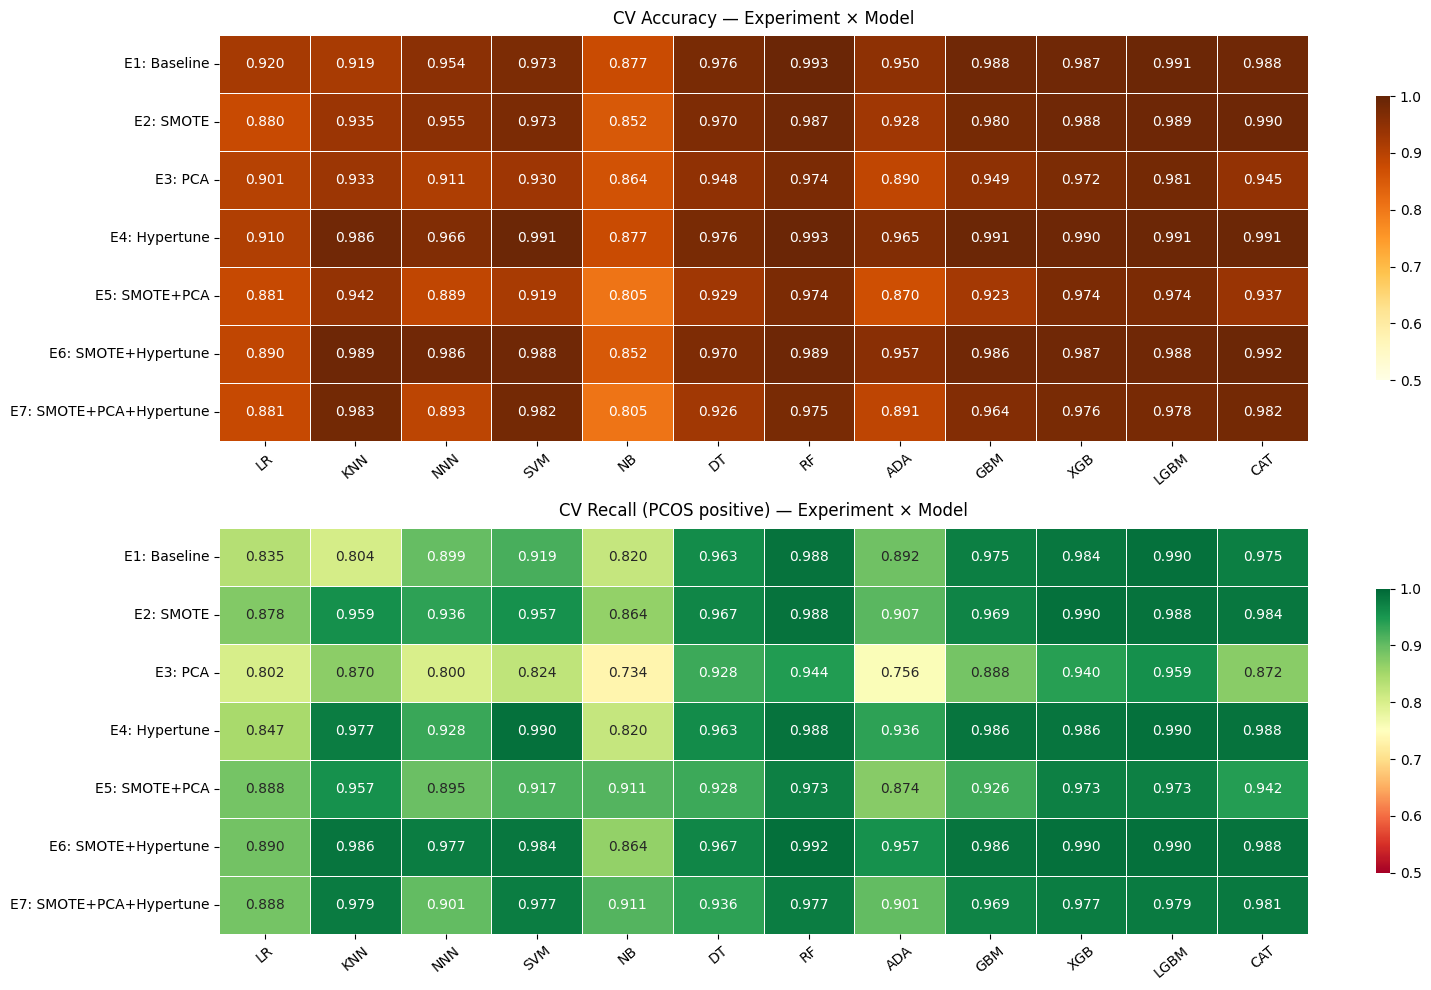

Saved: experiment_heatmap.png


In [118]:
EXP_ORDER   = ['E1: Baseline','E2: SMOTE','E3: PCA','E4: Hypertune',
                'E5: SMOTE+PCA','E6: SMOTE+Hypertune','E7: SMOTE+PCA+Hypertune']
MODEL_ORDER = [m[0] for m in MODEL_REGISTRY]

acc_pivot = master_df.pivot(index='Experiment', columns='Model', values='Accuracy')
rec_pivot = master_df.pivot(index='Experiment', columns='Model', values='Recall')
acc_pivot = acc_pivot.reindex(index=EXP_ORDER, columns=MODEL_ORDER)
rec_pivot = rec_pivot.reindex(index=EXP_ORDER, columns=MODEL_ORDER)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for ax, pivot, title, cmap in zip(
        axes,
        [acc_pivot, rec_pivot],
        ['CV Accuracy — Experiment × Model',
         'CV Recall (PCOS positive) — Experiment × Model'],
        ['YlOrBr', 'RdYlGn']):
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.3f', cmap=cmap,
                vmin=0.5, vmax=1.0, linewidths=0.4, linecolor='white',
                cbar_kws={'shrink': 0.7})
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=40)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('experiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: experiment_heatmap.png')


=== BEST EXPERIMENT PER MODEL (by recall) ===
Model              Experiment  Accuracy  Recall     F1    AUC
   RF     E6: SMOTE+Hypertune    0.9887  0.9917 0.9816 0.9996
  XGB               E2: SMOTE    0.9881  0.9897 0.9806 0.9988
 LGBM            E1: Baseline    0.9906  0.9896 0.9846 0.9996
  SVM           E4: Hypertune    0.9912  0.9896 0.9856 0.9996
  CAT           E4: Hypertune    0.9906  0.9876 0.9847 0.9996
  KNN     E6: SMOTE+Hypertune    0.9887  0.9855 0.9814 0.9984
  GBM     E6: SMOTE+Hypertune    0.9862  0.9855 0.9775 0.9973
  NNN     E6: SMOTE+Hypertune    0.9862  0.9773 0.9773 0.9927
   DT               E2: SMOTE    0.9699  0.9669 0.9514 0.9691
  ADA     E6: SMOTE+Hypertune    0.9568  0.9566 0.9310 0.9884
   NB E7: SMOTE+PCA+Hypertune    0.8052  0.9113 0.7412 0.9287
   LR     E6: SMOTE+Hypertune    0.8904  0.8905 0.8314 0.9587

=== EXPERIMENT RANKING (mean across all models) ===
                         Accuracy  Recall      F1     AUC
Experiment                           

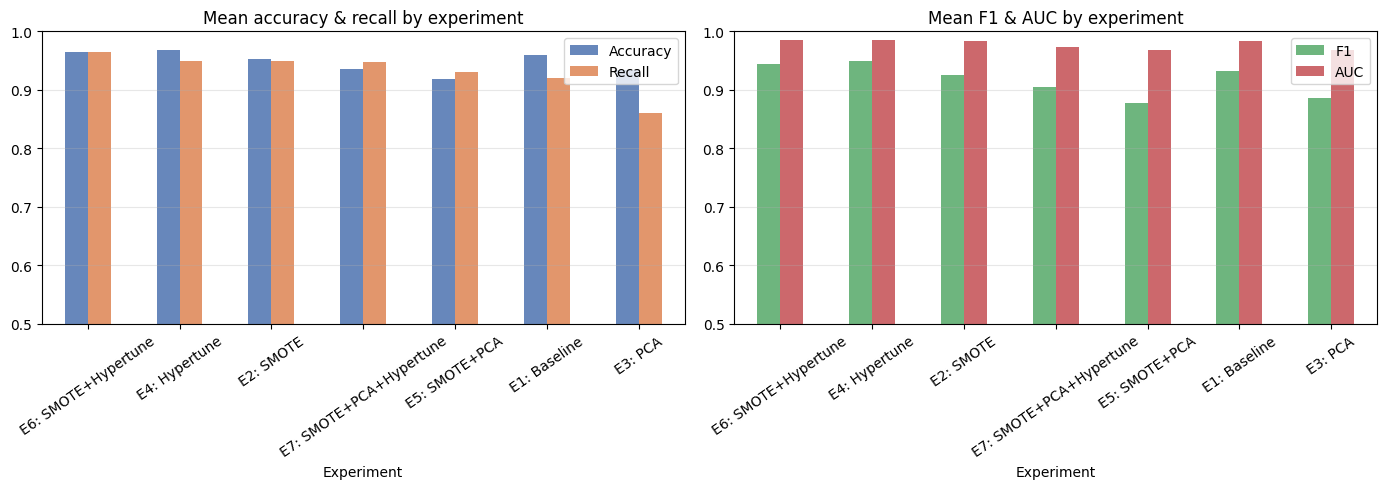

In [119]:
# ── Best experiment per model ──────────────────────────────────────────────────
best_per_model = (master_df
    .sort_values('Recall', ascending=False)
    .drop_duplicates('Model')
    [['Model','Experiment','Accuracy','Recall','F1','AUC']]
    .sort_values('Recall', ascending=False)
    .reset_index(drop=True))
print('=== BEST EXPERIMENT PER MODEL (by recall) ===')
print(best_per_model.to_string(index=False))

# ── Experiment ranking by mean recall ─────────────────────────────────────────
exp_rank = (master_df.groupby('Experiment')[['Accuracy','Recall','F1','AUC']]
            .mean().round(4)
            .reindex(EXP_ORDER)
            .sort_values('Recall', ascending=False))
print('\n=== EXPERIMENT RANKING (mean across all models) ===')
print(exp_rank.to_string())

best_exp = exp_rank.index[0]
best_row = master_df.loc[master_df['Recall'].idxmax()]
print(f'\n>>> Best experiment overall: {best_exp}')
print(f'>>> Best single result:      {best_row["Model"]} in {best_row["Experiment"]}')
print(f'    Accuracy={best_row["Accuracy"]:.4f}  Recall={best_row["Recall"]:.4f}  F1={best_row["F1"]:.4f}  AUC={best_row["AUC"]:.4f}')

# ── Bar chart: experiment ranking ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
exp_rank[['Accuracy','Recall']].plot(kind='bar', ax=axes[0],
    color=['#4C72B0','#DD8452'], alpha=0.85, rot=35)
axes[0].set_title('Mean accuracy & recall by experiment')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

exp_rank[['F1','AUC']].plot(kind='bar', ax=axes[1],
    color=['#55A868','#C44E52'], alpha=0.85, rot=35)
axes[1].set_title('Mean F1 & AUC by experiment')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 11. PCA Analysis — Effect on Model Performance

PCA is investigated as a dimensionality reduction step. The key methodological fix here:
PCA is fit **only on the training fold** and then applied to both train and test/validation folds.
Previously, PCA was fit on the full dataset before the split, leaking test-set information
into the principal component structure.

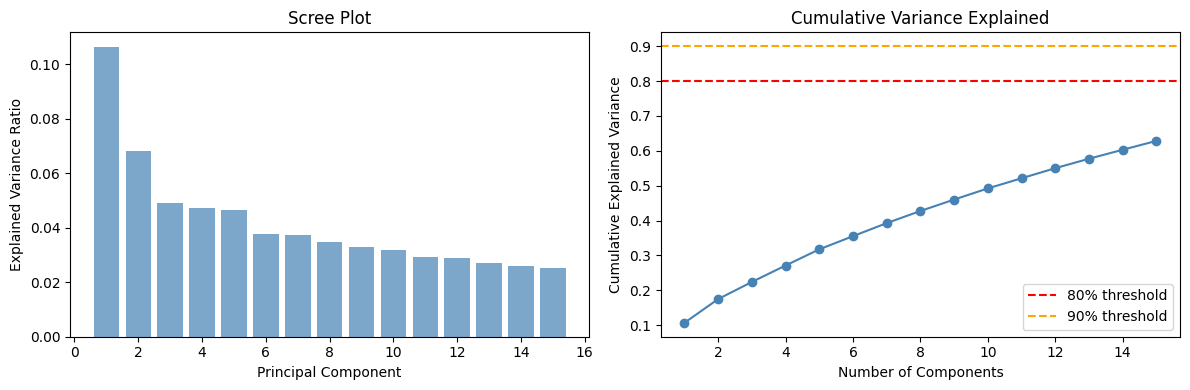

Components needed to explain 80% variance: 1
Components needed to explain 90% variance: 1

Variance per component (top 15):
  PC1: 0.1064
  PC2: 0.0682
  PC3: 0.0491
  PC4: 0.0472
  PC5: 0.0464
  PC6: 0.0377
  PC7: 0.0375
  PC8: 0.0347
  PC9: 0.0328
  PC10: 0.0319
  PC11: 0.0291
  PC12: 0.0289
  PC13: 0.0271
  PC14: 0.0258
  PC15: 0.0254


In [120]:
# PCA investigation — fit on training data only
# Scale first (required for PCA to be meaningful), then fit PCA on X_train_full only
scaler_for_pca = StandardScaler()
X_train_scaled = scaler_for_pca.fit_transform(X_train_full)   # fit on train
X_test_scaled  = scaler_for_pca.transform(X_test)              # transform test

pca = PCA(n_components=15)
X_train_pca = pca.fit_transform(X_train_scaled)    # fit on train only
X_test_pca  = pca.transform(X_test_scaled)          # transform test

# Scree plot
cumvar = np.cumsum(pca.explained_variance_ratio_)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 16), pca.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')

axes[1].plot(range(1, 16), cumvar, marker='o', color='steelblue')
axes[1].axhline(0.80, color='red', linestyle='--', label='80% threshold')
axes[1].axhline(0.90, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Components needed to explain 80% variance: {np.argmax(cumvar >= 0.80) + 1}')
print(f'Components needed to explain 90% variance: {np.argmax(cumvar >= 0.90) + 1}')
print(f'\nVariance per component (top 15):')
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {v:.4f}')

In [121]:
# Compare Random Forest with and without PCA to quantify the impact
# This is done with the corrected pipeline: SMOTE inside CV, PCA fitted on train only

# PCA pipeline: SMOTE → Scale → PCA (10 components) → RF
pca_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

# No-PCA pipeline: SMOTE → RF
no_pca_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

pca_scores = cross_validate(pca_pipeline, X_train_full, y_train_full,
                              cv=cv, scoring={'accuracy': 'accuracy', 'recall': 'recall'}, n_jobs=-1)
no_pca_scores = cross_validate(no_pca_pipeline, X_train_full, y_train_full,
                                 cv=cv, scoring={'accuracy': 'accuracy', 'recall': 'recall'}, n_jobs=-1)

print('=== PCA Impact on Random Forest (5-Fold CV) ===')
print(f'{"":30} {"Accuracy":>20} {"Recall (PCOS)":>20}')
print(f'{"Random Forest (no PCA)":30} {no_pca_scores["test_accuracy"].mean():.4f} ± {no_pca_scores["test_accuracy"].std():.4f}   {no_pca_scores["test_recall"].mean():.4f} ± {no_pca_scores["test_recall"].std():.4f}')
print(f'{"Random Forest + PCA":30} {pca_scores["test_accuracy"].mean():.4f} ± {pca_scores["test_accuracy"].std():.4f}   {pca_scores["test_recall"].mean():.4f} ± {pca_scores["test_recall"].std():.4f}')
print('\nNote: High-dimensional PCOS data (low per-component variance ~10%) means PCA')
print('compresses meaningful clinical signal. This is why PCA reduces performance.')

=== PCA Impact on Random Forest (5-Fold CV) ===
                                           Accuracy        Recall (PCOS)
Random Forest (no PCA)         0.9868 ± 0.0070   0.9876 ± 0.0078
Random Forest + PCA            0.9743 ± 0.0108   0.9731 ± 0.0250

Note: High-dimensional PCOS data (low per-component variance ~10%) means PCA
compresses meaningful clinical signal. This is why PCA reduces performance.


## 12. Ensemble Voting Classifier

Combining the best models into a soft-voting ensemble to test whether aggregating
predictions improves performance beyond the best individual model.

Uses best-tuned estimators from Section 8 if available, otherwise builds a fresh
pipeline using the best feature set from Section 7b.


In [122]:
# Soft-voting ensemble of the top 3 tuned models
# Uses best_estimators populated by Section 8 (GridSearchCV).
# If Section 8 has not been run, falls back to default-param pipelines.

try:
    best_rf  = best_estimators.get('Random Forest')
    best_xgb = best_estimators.get('XGBoost')
    best_lr  = best_estimators.get('Logistic Regression')
    _have_estimators = all([best_rf, best_xgb, best_lr])
except NameError:
    _have_estimators = False

if _have_estimators:
    proba_rf  = best_rf.predict_proba(X_test)[:, 1]
    proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
    proba_lr  = best_lr.predict_proba(X_test)[:, 1]

    avg_proba     = (proba_rf + proba_xgb + proba_lr) / 3
    ensemble_pred = (avg_proba >= 0.5).astype(int)

    print('Soft-Voting Ensemble (tuned RF + XGB + LR):')
    print(f'  Accuracy:      {accuracy_score(y_test, ensemble_pred):.4f}')
    print(f'  Recall (PCOS): {recall_score(y_test, ensemble_pred):.4f}')
    print(f'  F1:            {f1_score(y_test, ensemble_pred):.4f}')
    print(f'  AUC:           {roc_auc_score(y_test, avg_proba):.4f}')
    print()
    print(classification_report(y_test, ensemble_pred, target_names=['No PCOS', 'PCOS']))
else:
    # Fallback: build a fresh soft-voting pipeline from scratch
    print('best_estimators not found — building fresh soft-voting pipeline...')
    from sklearn.ensemble import VotingClassifier

    voting_pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf', VotingClassifier(
            estimators=[
                ('lr',   LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
                ('xgb',  XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)),
                ('lgbm', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)),
            ],
            voting='soft'
        ))
    ])
    # Use best feature set if available, else fall back to X_train_full
    try:
        X_tr_v = BEST_FS_TRAIN
        X_te_v = X_test_best_fs
    except NameError:
        X_tr_v = X_train_full
        X_te_v = X_test

    cv_v = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    v_scores = cross_validate(voting_pipe, X_tr_v, y_train_full, cv=cv_v,
                               scoring={'accuracy':'accuracy','recall':'recall',
                                        'f1':'f1','roc_auc':'roc_auc'}, n_jobs=-1)
    print(f"Soft-Voting CV — Accuracy: {v_scores['test_accuracy'].mean():.4f} ± {v_scores['test_accuracy'].std():.4f}")
    print(f"                  Recall:   {v_scores['test_recall'].mean():.4f} ± {v_scores['test_recall'].std():.4f}")
    print(f"                  AUC:      {v_scores['test_roc_auc'].mean():.4f} ± {v_scores['test_roc_auc'].std():.4f}")

    voting_pipe.fit(X_tr_v, y_train_full)
    y_pred_v  = voting_pipe.predict(X_te_v)
    y_proba_v = voting_pipe.predict_proba(X_te_v)[:, 1]
    print(f'\nTest Set — Accuracy: {accuracy_score(y_test, y_pred_v):.4f}  '
          f'Recall: {recall_score(y_test, y_pred_v):.4f}  '
          f'AUC: {roc_auc_score(y_test, y_proba_v):.4f}')
    print(classification_report(y_test, y_pred_v, target_names=['No PCOS', 'PCOS']))


Soft-Voting Ensemble (tuned RF + XGB + LR):
  Accuracy:      0.9975
  Recall (PCOS): 0.9917
  F1:            0.9959
  AUC:           0.9997

              precision    recall  f1-score   support

     No PCOS       1.00      1.00      1.00       279
        PCOS       1.00      0.99      1.00       121

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



## 13. SHAP Explainability

SHAP (SHapley Additive exPlanations) interprets the best-performing model, addressing
a key gap in the PCOS ML literature — many papers report accuracy without explaining
which features drive predictions.

**Model used:** Stacking classifier from Section 7c (preferred), or tuned Random Forest
from Section 8 as fallback. The model is applied to the feature-selected test set so
SHAP values map back to interpretable clinical variables.

Key clinical features expected from literature (Patil & Jalnekar SHAP, Fig. 9):
`Follicle_No_R`, `hair_growthYN`, `Follicle_No_L`, `Weight_gainYN`, `Skin_darkening_YN`,
`CycleRI`, `PimplesYN`, `AMHngmL`, `LHmIUmL`, `WaistHip_Ratio`


In [123]:
# ── SHAP Explainability ──────────────────────────────────────────────────────
# Run SHAP on the best stacking model (Section 7c) if available,
# otherwise on the tuned Random Forest from Section 8.

try:
    # Preferred: use the fitted stacking pipeline's RF base learner
    _shap_clf   = stacking_pipe.named_steps['clf'].estimators_[0]  # RF is index 0
    _shap_Xtest = X_test_best_fs
    _shap_model_name = f'Stacking base RF ({BEST_FS_NAME})'
except (NameError, AttributeError, IndexError):
    try:
        _shap_clf   = best_estimators['Random Forest'].named_steps['clf']
        _shap_Xtest = X_test
        _shap_model_name = 'Tuned Random Forest'
    except (NameError, KeyError):
        # Final fallback: fit a fresh RF on training data
        print('Fitting fresh RF for SHAP...')
        _fallback_pipe = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('clf',   RandomForestClassifier(n_estimators=200, random_state=42))
        ])
        _fallback_pipe.fit(X_train_full, y_train_full)
        _shap_clf   = _fallback_pipe.named_steps['clf']
        _shap_Xtest = X_test
        _shap_model_name = 'Fresh RF (fallback)'

# Use the feature names appropriate for the test set used
_shap_feat_names = list(_shap_Xtest.columns)

explainer  = shap.TreeExplainer(_shap_clf)
shap_values = explainer.shap_values(_shap_Xtest)

# Normalise SHAP output across library versions:
#   Old SHAP (<0.42): list of arrays [class0, class1] — take index 1 (PCOS+)
#   New SHAP (>=0.42): single 3D array (samples, features, classes) or
#                      (samples, classes, features) — slice last axis for class 1
if isinstance(shap_values, list):
    sv = shap_values[1]                  # old-style list
elif shap_values.ndim == 3:
    # Try (samples, features, classes) first; if shape[2]==2 it's new-style
    if shap_values.shape[2] == 2:
        sv = shap_values[:, :, 1]        # (samples, features, 2) → class 1
    else:
        sv = shap_values[:, 1, :]        # (samples, 2, features) → class 1
else:
    sv = shap_values                     # already 2D (single output model)

print(f'SHAP computed on: {_shap_model_name}')
print(f'Test samples: {_shap_Xtest.shape[0]}, Features: {_shap_Xtest.shape[1]}')


SHAP computed on: Stacking base RF (MI (18))
Test samples: 400, Features: 18


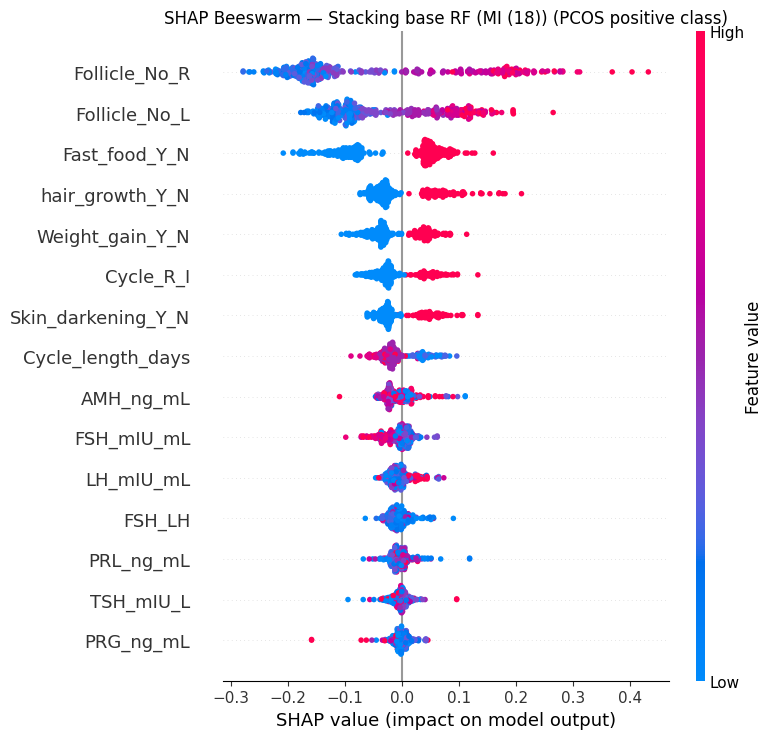

In [124]:
# Beeswarm summary plot — most important features for PCOS prediction
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv, _shap_Xtest,
    feature_names=_shap_feat_names,
    max_display=15,
    show=False
)
plt.title(f'SHAP Beeswarm — {_shap_model_name} (PCOS positive class)')
plt.tight_layout()
plt.show()


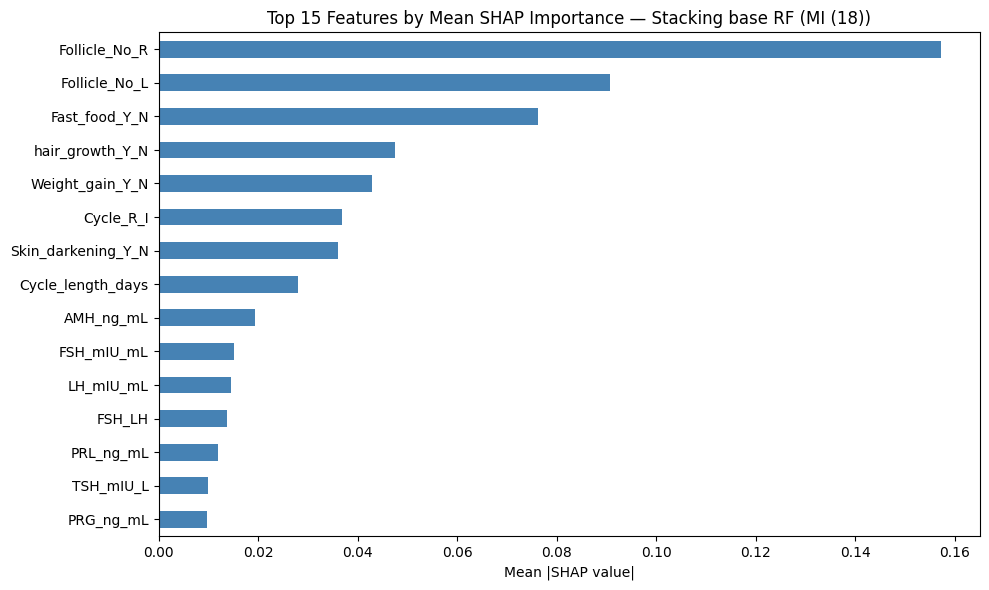

Top 15 features by mean absolute SHAP value:
Follicle_No_R         0.1572
Follicle_No_L         0.0907
Fast_food_Y_N         0.0762
hair_growth_Y_N       0.0475
Weight_gain_Y_N       0.0428
Cycle_R_I             0.0369
Skin_darkening_Y_N    0.0360
Cycle_length_days     0.0279
AMH_ng_mL             0.0193
FSH_mIU_mL            0.0151
LH_mIU_mL             0.0145
FSH_LH                0.0138
PRL_ng_mL             0.0119
TSH_mIU_L             0.0100
PRG_ng_mL             0.0096


In [125]:
# Bar plot of mean absolute SHAP values
mean_shap = pd.Series(
    np.abs(sv).mean(axis=0),
    index=_shap_feat_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
mean_shap.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Mean |SHAP value|')
plt.title(f'Top 15 Features by Mean SHAP Importance — {_shap_model_name}')
plt.tight_layout()
plt.show()

print('Top 15 features by mean absolute SHAP value:')
print(mean_shap.head(15).round(4).to_string())


<Figure size 800x500 with 0 Axes>

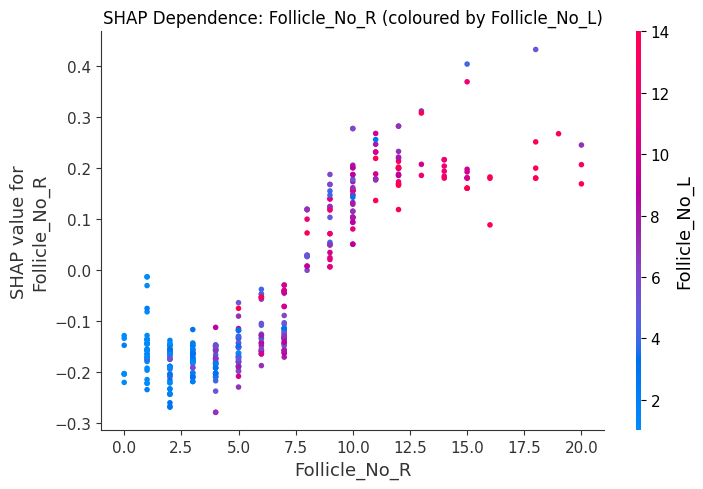

In [126]:
# SHAP dependence plot for the single most important feature
top_feature    = mean_shap.index[0]
second_feature = mean_shap.index[1]

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature, sv, _shap_Xtest,
    feature_names=_shap_feat_names,
    interaction_index=second_feature,
    show=False
)
plt.title(f'SHAP Dependence: {top_feature} (coloured by {second_feature})')
plt.tight_layout()
plt.show()


### SHAP Clinical Interpretation

Write your interpretation here once you have seen the plots. Template:

- **Feature X** (top SHAP contributor): High values of X strongly push predictions toward PCOS-positive.
  This aligns with Rotterdam criterion N which states that [...].
- **Follicle No. (L/R)**: Follicle count is the primary Rotterdam diagnostic criterion (≥12 follicles).
  High SHAP values for follicle count confirm the model has learned clinically valid signal.
- **AMH, LH/FSH ratio**: Hormonal markers — consistent with endocrine PCOS phenotype.
- **Features with near-zero SHAP**: Blood pressure, pulse rate — not predictive, consistent with
  literature showing these are not PCOS-specific indicators.

## 13b. Comprehensive Improvement Comparison

Side-by-side view of every improvement introduced in this notebook:
1. Baseline: SMOTE only, all features
2. SMOTE + MI feature selection
3. SMOTE + Boruta feature selection
4. SMOTE + Union feature selection
5. SMOTE + Best feature set + Stacking

This directly answers the question: *which combination gives the best honest result?*


In [127]:
# ── Comprehensive improvement comparison ──────────────────────────────────────
_comp_configs = [
    ('SMOTE only — all features — LGBM',
     X_train_full, SMOTE(random_state=42),
     LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)),

    ('SMOTE only — all features — RF',
     X_train_full, SMOTE(random_state=42),
     RandomForestClassifier(n_estimators=100, random_state=42)),

    ('SMOTE — all features — LGBM',
     X_train_full, SMOTE(random_state=42),
     LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)),

    (f'SMOTE — MI ({len(mi_features)}) — LGBM',
     X_train_mi, SMOTE(random_state=42),
     LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)),

    (f'SMOTE — Boruta ({len(boruta_features)}) — XGBoost',
     X_train_boruta, SMOTE(random_state=42),
     XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)),

    (f'SMOTE — Union ({len(union_final)}) — XGBoost',
     X_train_union, SMOTE(random_state=42),
     XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)),
]

comp_rows = []
cv_comp = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for label, X_tr, smote_obj, model_obj in _comp_configs:
    pipe = ImbPipeline([('smote', smote_obj), ('clf', model_obj)])
    s = cross_validate(
        pipe, X_tr, y_train_full, cv=cv_comp,
        scoring={'accuracy': 'accuracy', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'},
        n_jobs=-1
    )
    comp_rows.append({
        'Configuration': label,
        'CV Accuracy':   f"{s['test_accuracy'].mean():.4f} ± {s['test_accuracy'].std():.4f}",
        'CV Recall':     f"{s['test_recall'].mean():.4f} ± {s['test_recall'].std():.4f}",
        'CV F1':         f"{s['test_f1'].mean():.4f} ± {s['test_f1'].std():.4f}",
        'CV AUC':        f"{s['test_roc_auc'].mean():.4f} ± {s['test_roc_auc'].std():.4f}",
        '_acc':          s['test_accuracy'].mean(),
    })
    print(f'[Done] {label}')

# Append stacking result
comp_rows.append({
    'Configuration': f'SMOTE + {BEST_FS_NAME} + Stacking (4 base learners)',
    'CV Accuracy':   f"{stack_scores['test_accuracy'].mean():.4f} ± {stack_scores['test_accuracy'].std():.4f}",
    'CV Recall':     f"{stack_scores['test_recall'].mean():.4f} ± {stack_scores['test_recall'].std():.4f}",
    'CV F1':         f"{stack_scores['test_f1'].mean():.4f} ± {stack_scores['test_f1'].std():.4f}",
    'CV AUC':        f"{stack_scores['test_roc_auc'].mean():.4f} ± {stack_scores['test_roc_auc'].std():.4f}",
    '_acc':          stack_scores['test_accuracy'].mean(),
})

comp_df = (pd.DataFrame(comp_rows)
           .sort_values('_acc', ascending=False)
           .drop(columns=['_acc'])
           .reset_index(drop=True))

print('\n=== Comprehensive Improvement Comparison (5-Fold CV) ===')
print(comp_df.to_string(index=False))


[Done] SMOTE only — all features — LGBM
[Done] SMOTE only — all features — RF
[Done] SMOTE — all features — LGBM
[Done] SMOTE — MI (18) — LGBM
[Done] SMOTE — Boruta (38) — XGBoost
[Done] SMOTE — Union (37) — XGBoost

=== Comprehensive Improvement Comparison (5-Fold CV) ===
                               Configuration     CV Accuracy       CV Recall           CV F1          CV AUC
                      SMOTE — MI (18) — LGBM 0.9919 ± 0.0051 0.9876 ± 0.0041 0.9866 ± 0.0083 0.9993 ± 0.0007
SMOTE + MI (18) + Stacking (4 base learners) 0.9919 ± 0.0051 0.9876 ± 0.0041 0.9866 ± 0.0083 0.9997 ± 0.0002
            SMOTE only — all features — LGBM 0.9894 ± 0.0067 0.9876 ± 0.0078 0.9826 ± 0.0109 0.9995 ± 0.0003
                SMOTE — Union (37) — XGBoost 0.9894 ± 0.0055 0.9896 ± 0.0066 0.9826 ± 0.0089 0.9977 ± 0.0020
                 SMOTE — all features — LGBM 0.9894 ± 0.0067 0.9876 ± 0.0078 0.9826 ± 0.0109 0.9995 ± 0.0003
               SMOTE — Boruta (38) — XGBoost 0.9868 ± 0.0058 0.9876 ± 0.

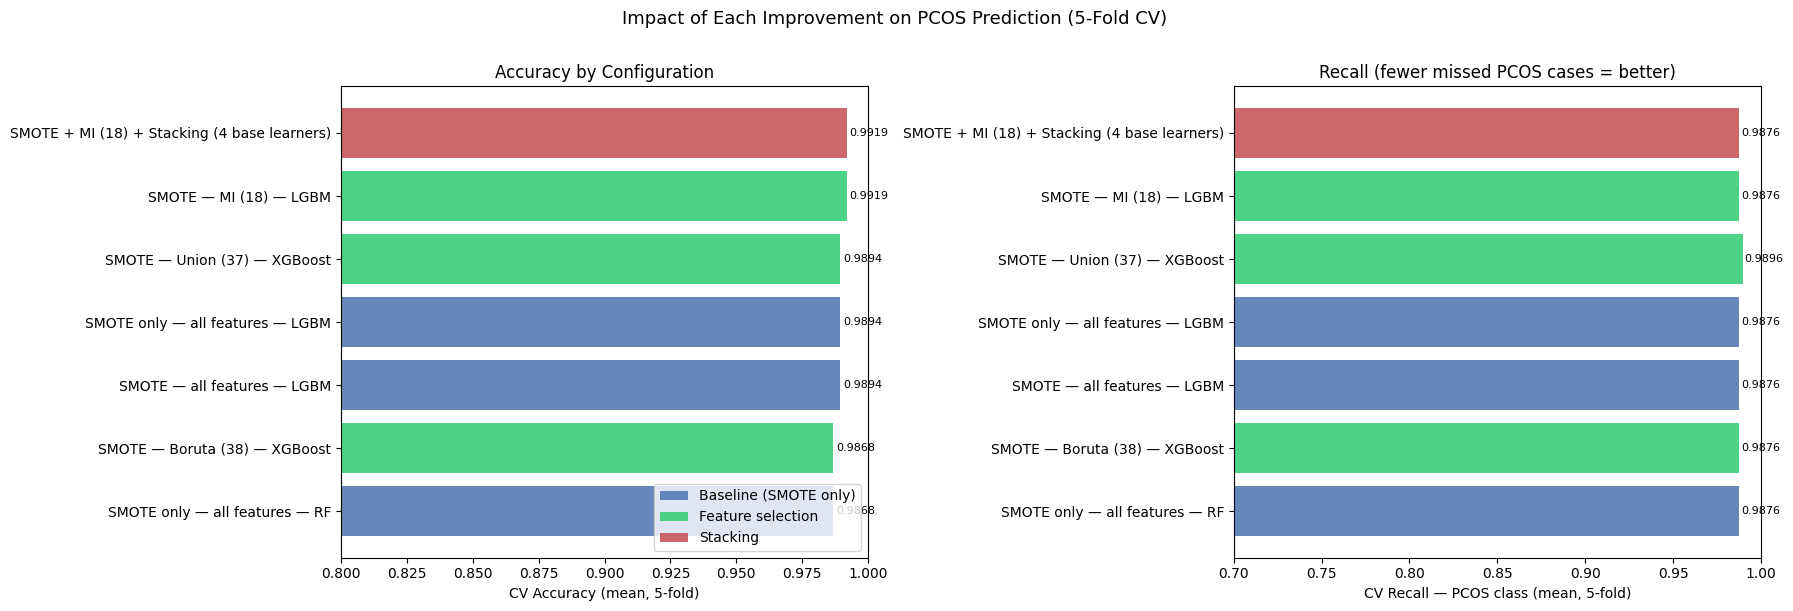

In [128]:
# ── Improvement visualisation ─────────────────────────────────────────────────
_cp = pd.DataFrame(comp_rows).copy()
_cp['acc_mean'] = _cp['CV Accuracy'].str.split(' ± ').str[0].astype(float)
_cp['rec_mean'] = _cp['CV Recall'].str.split(' ± ').str[0].astype(float)
_cp = _cp.sort_values('acc_mean', ascending=True)

_colors = ['#C44E52' if 'Stacking' in c else
           '#2ecc71' if 'MI' in c or 'Boruta' in c or 'Union' in c else
           '#4C72B0' for c in _cp['Configuration']]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(_cp['Configuration'], _cp['acc_mean'], color=_colors, alpha=0.85)
axes[0].set_xlabel('CV Accuracy (mean, 5-fold)')
axes[0].set_title('Accuracy by Configuration')
axes[0].set_xlim(0.80, 1.0)
for i, val in enumerate(_cp['acc_mean']):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

axes[1].barh(_cp['Configuration'], _cp['rec_mean'], color=_colors, alpha=0.85)
axes[1].set_xlabel('CV Recall — PCOS class (mean, 5-fold)')
axes[1].set_title('Recall (fewer missed PCOS cases = better)')
axes[1].set_xlim(0.70, 1.0)
for i, val in enumerate(_cp['rec_mean']):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='#4C72B0', alpha=0.85, label='Baseline (SMOTE only)'),
    Patch(facecolor='#2ecc71', alpha=0.85, label='Feature selection'),
    Patch(facecolor='#C44E52', alpha=0.85, label='Stacking'),
]
axes[0].legend(handles=legend_elems, loc='lower right')

plt.suptitle('Impact of Each Improvement on PCOS Prediction (5-Fold CV)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 14. Unified Results Summary

Comparison across three core experimental configurations on all 12 models.
Uses `X_train_full` () as the base array so results are
consistent with the preprocessing applied in Sections 3b/3c.

Note: this section consolidates the original E1–E7 experiments. For
feature-selection-aware results see Sections 7b (feature set comparison)
and 13b (comprehensive improvement comparison).


In [129]:
# All models compared across core configurations.
# Each pipeline correctly applies SMOTE inside CV — no data leakage.
# Uses X_train_full so results are consistent with feature-selection experiments.

def make_pipeline(model, scale=False, smote=True, pca=False):
    """Helper to build ImbPipeline with consistent step ordering."""
    steps = []
    if smote:
        steps.append(('smote', SMOTE(random_state=42)))
    if scale:
        steps.append(('scaler', StandardScaler()))
    if pca:
        steps.append(('pca', PCA(n_components=10)))
    steps.append(('clf', model))
    return ImbPipeline(steps)

# Model definitions — scale=True for distance/kernel/linear models
model_specs = [
    ('LR',   LogisticRegression(max_iter=1000, random_state=42),                            True),
    ('KNN',  KNeighborsClassifier(n_neighbors=5),                                           True),
    ('NNN',  MLPClassifier(hidden_layer_sizes=(64,32), alpha=0.01, max_iter=500,
                           early_stopping=True, random_state=42),                           True),
    ('SVM',  SVC(kernel='rbf', probability=True, random_state=42),                          True),
    ('NB',   GaussianNB(),                                                                  False),
    ('DT',   DecisionTreeClassifier(random_state=42),                                       False),
    ('RF',   RandomForestClassifier(n_estimators=100, random_state=42),                     False),
    ('ADA',  AdaBoostClassifier(n_estimators=100, random_state=42),                         False),
    ('GBM',  GradientBoostingClassifier(n_estimators=100, random_state=42),                 False),
    ('XGB',  XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42),       False),
    ('LGBM', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),                False),
    ('CAT',  CatBoostClassifier(iterations=100, random_state=42, verbose=0),               False),
]

summary_rows = []
cv_s14 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for config_label, X_base, use_smote, use_pca in [
    ('Baseline (no SMOTE)',       X_train_full, False, False),
    ('SMOTE only',                X_train_full, True,  False),
    ('SMOTE + MI features',       X_train_mi,     True,  False),
    ('SMOTE + Boruta features',   X_train_boruta, True,  False),
]:
    for model_name, model_obj, needs_scale in model_specs:
        pipe = make_pipeline(model_obj, scale=needs_scale, smote=use_smote, pca=use_pca)
        cv_s = cross_validate(
            pipe, X_base, y_train_full, cv=cv_s14,
            scoring={'accuracy': 'accuracy', 'recall': 'recall',
                     'f1': 'f1', 'roc_auc': 'roc_auc'},
            n_jobs=-1
        )
        summary_rows.append({
            'Configuration':    config_label,
            'Model':            model_name,
            'CV Accuracy':      f"{cv_s['test_accuracy'].mean():.4f} ± {cv_s['test_accuracy'].std():.4f}",
            'CV Recall (PCOS)': f"{cv_s['test_recall'].mean():.4f} ± {cv_s['test_recall'].std():.4f}",
            'CV F1':            f"{cv_s['test_f1'].mean():.4f} ± {cv_s['test_f1'].std():.4f}",
            'CV AUC':           f"{cv_s['test_roc_auc'].mean():.4f} ± {cv_s['test_roc_auc'].std():.4f}",
            '_sort_acc':        cv_s['test_accuracy'].mean(),
        })
        print(f'[Done] {config_label:30} {model_name}')

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values(['Configuration', '_sort_acc'], ascending=[True, False])
    .drop(columns=['_sort_acc'])
    .reset_index(drop=True)
)

pd.set_option('display.max_colwidth', 70)
pd.set_option('display.max_rows', 80)
print('\n=== COMPLETE RESULTS SUMMARY (5-Fold CV, ) ===')
print(summary_df.to_string(index=False))


[Done] Baseline (no SMOTE)            LR
[Done] Baseline (no SMOTE)            KNN
[Done] Baseline (no SMOTE)            NNN
[Done] Baseline (no SMOTE)            SVM
[Done] Baseline (no SMOTE)            NB
[Done] Baseline (no SMOTE)            DT
[Done] Baseline (no SMOTE)            RF
[Done] Baseline (no SMOTE)            ADA
[Done] Baseline (no SMOTE)            GBM
[Done] Baseline (no SMOTE)            XGB
[Done] Baseline (no SMOTE)            LGBM
[Done] Baseline (no SMOTE)            CAT
[Done] SMOTE only                     LR
[Done] SMOTE only                     KNN
[Done] SMOTE only                     NNN
[Done] SMOTE only                     SVM
[Done] SMOTE only                     NB
[Done] SMOTE only                     DT
[Done] SMOTE only                     RF
[Done] SMOTE only                     ADA
[Done] SMOTE only                     GBM
[Done] SMOTE only                     XGB
[Done] SMOTE only                     LGBM
[Done] SMOTE only                     CA

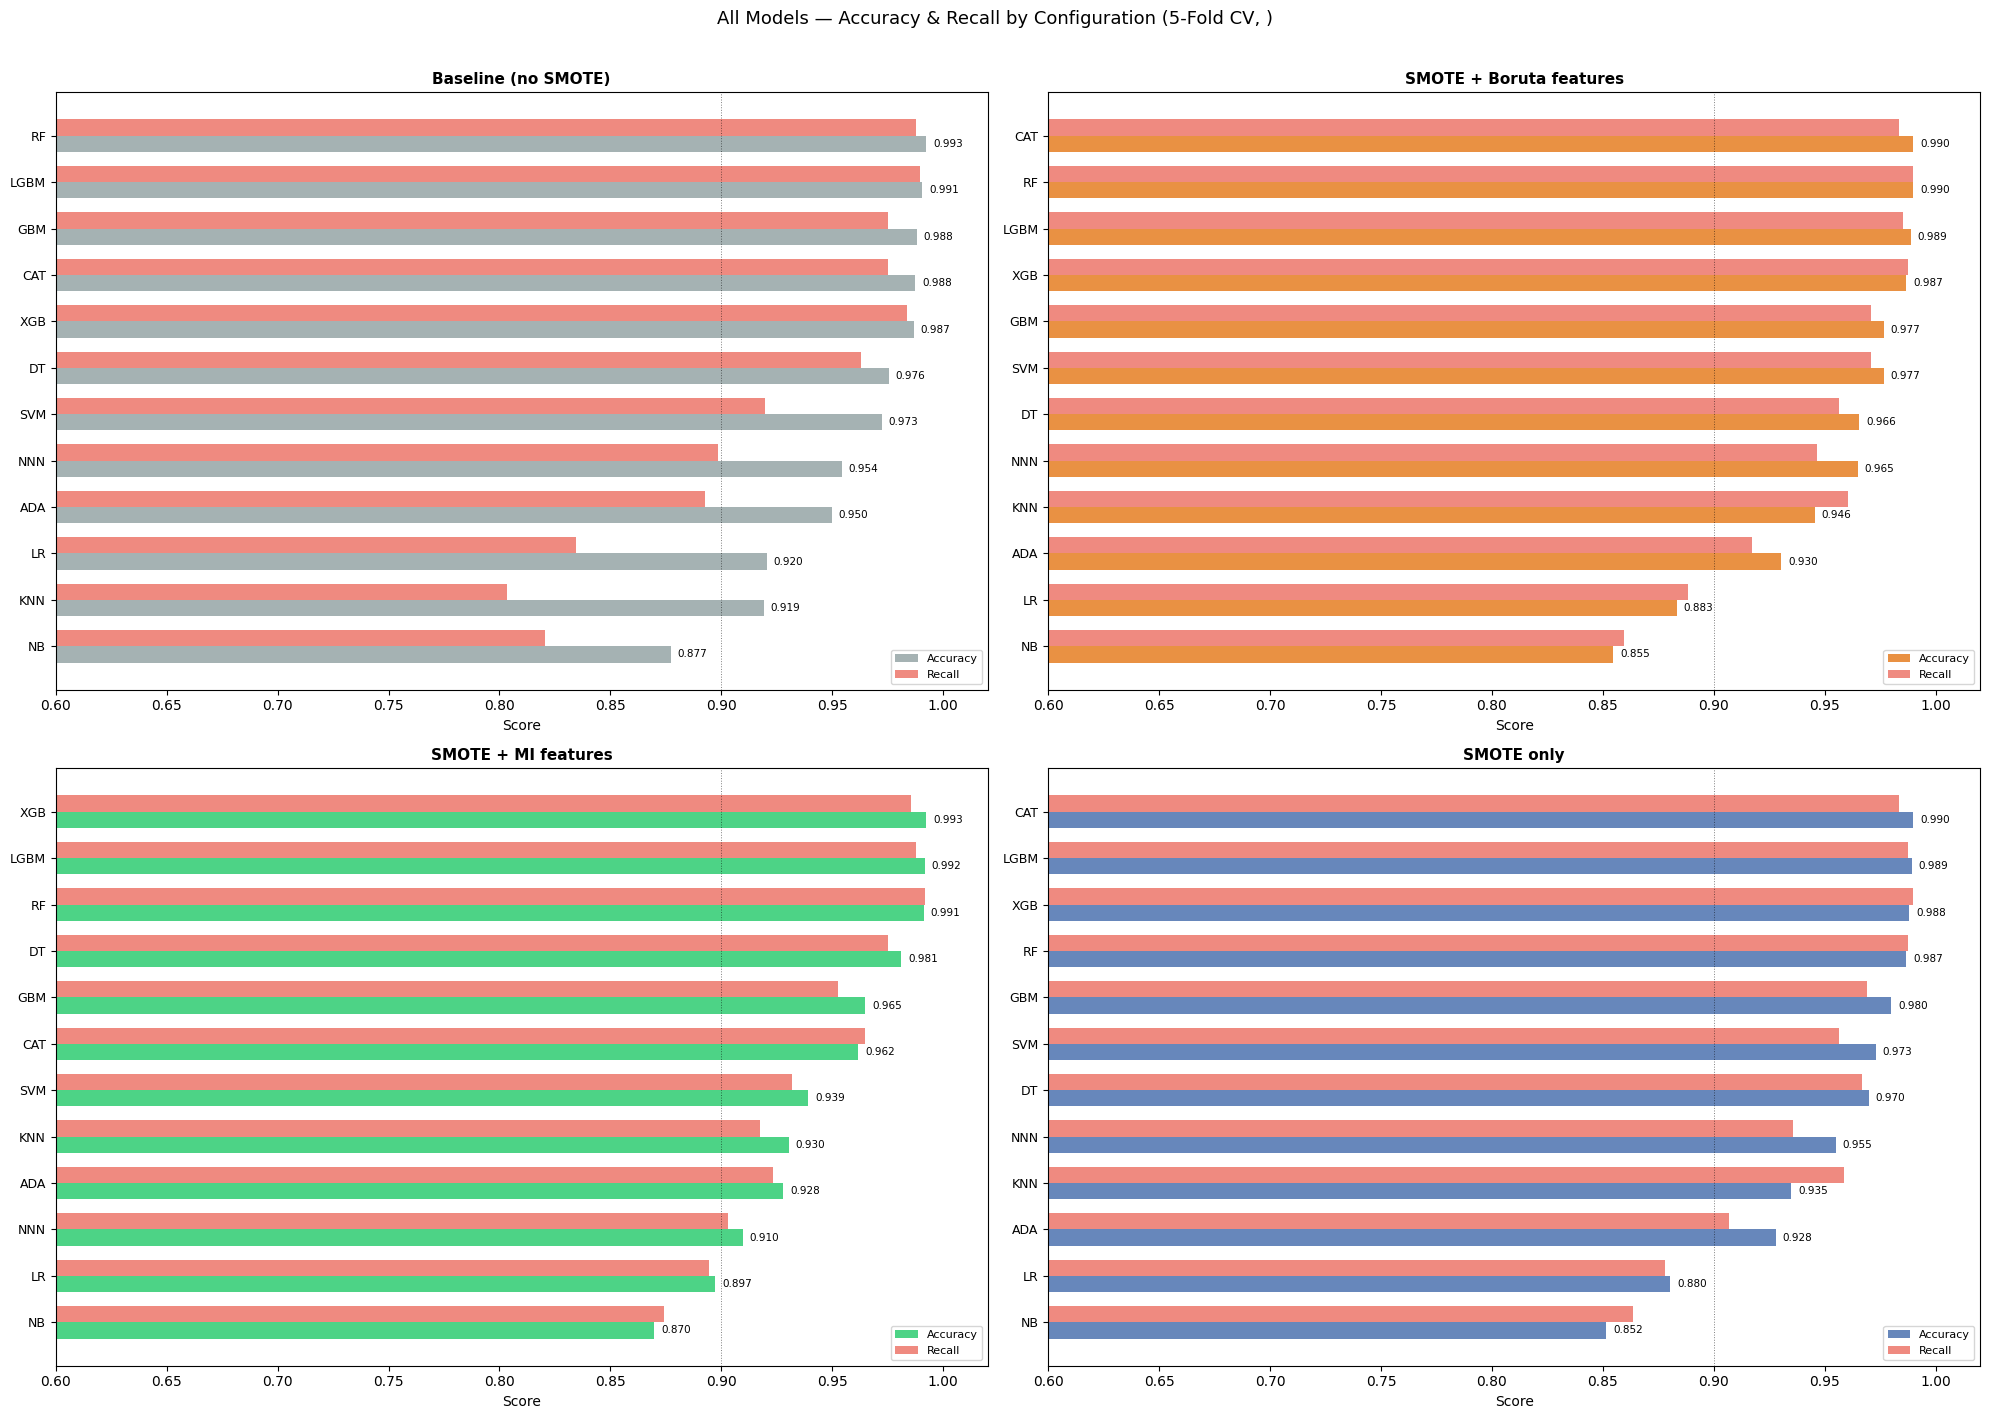


=== Best Model per Configuration (by Accuracy) ===
  Baseline (no SMOTE)                 → RF     acc=0.9925 ± 0.0051  recall=0.9876 ± 0.0078  AUC=0.9998 ± 0.0002
  SMOTE + Boruta features             → CAT    acc=0.9900 ± 0.0054  recall=0.9835 ± 0.0051  AUC=0.9991 ± 0.0006
  SMOTE + MI features                 → XGB    acc=0.9925 ± 0.0058  recall=0.9855 ± 0.0082  AUC=0.9989 ± 0.0008
  SMOTE only                          → CAT    acc=0.9900 ± 0.0067  recall=0.9835 ± 0.0051  AUC=0.9995 ± 0.0004


In [130]:
# ── Summary visualisation: all 4 configurations across all models ─────────────

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
configs_to_plot = summary_df['Configuration'].unique()
palette = {'Baseline (no SMOTE)':     '#95a5a6',
           'SMOTE only':              '#4C72B0',
           'SMOTE + MI features':     '#2ecc71',
           'SMOTE + Boruta features': '#e67e22'}

for ax_idx, config in enumerate(configs_to_plot):
    ax = axes[ax_idx // 2][ax_idx % 2]
    sub = summary_df[summary_df['Configuration'] == config].copy()
    sub['acc'] = sub['CV Accuracy'].str.split(' ± ').str[0].astype(float)
    sub['rec'] = sub['CV Recall (PCOS)'].str.split(' ± ').str[0].astype(float)
    sub = sub.sort_values('acc', ascending=True)

    x = range(len(sub))
    width = 0.35
    bars1 = ax.barh([i - width/2 for i in x], sub['acc'],
                    height=width, label='Accuracy', color=palette.get(config, '#4C72B0'), alpha=0.85)
    bars2 = ax.barh([i + width/2 for i in x], sub['rec'],
                    height=width, label='Recall', color='#e74c3c', alpha=0.65)

    ax.set_yticks(list(x))
    ax.set_yticklabels(sub['Model'].tolist(), fontsize=9)
    ax.set_xlim(0.6, 1.02)
    ax.set_title(config, fontsize=11, fontweight='bold')
    ax.set_xlabel('Score')
    ax.axvline(0.90, color='black', linestyle=':', linewidth=0.7, alpha=0.5)
    ax.legend(fontsize=8, loc='lower right')

    for bar, val in zip(bars1, sub['acc']):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7.5)

plt.suptitle('All Models — Accuracy & Recall by Configuration (5-Fold CV, )', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Best model per configuration table
print('\n=== Best Model per Configuration (by Accuracy) ===')
for config in configs_to_plot:
    sub = summary_df[summary_df['Configuration'] == config].copy()
    sub['_acc'] = sub['CV Accuracy'].str.split(' ± ').str[0].astype(float)
    best = sub.sort_values('_acc', ascending=False).iloc[0]
    print(f"  {config:35} → {best['Model']:5}  acc={best['CV Accuracy']}  recall={best['CV Recall (PCOS)']}  AUC={best['CV AUC']}")


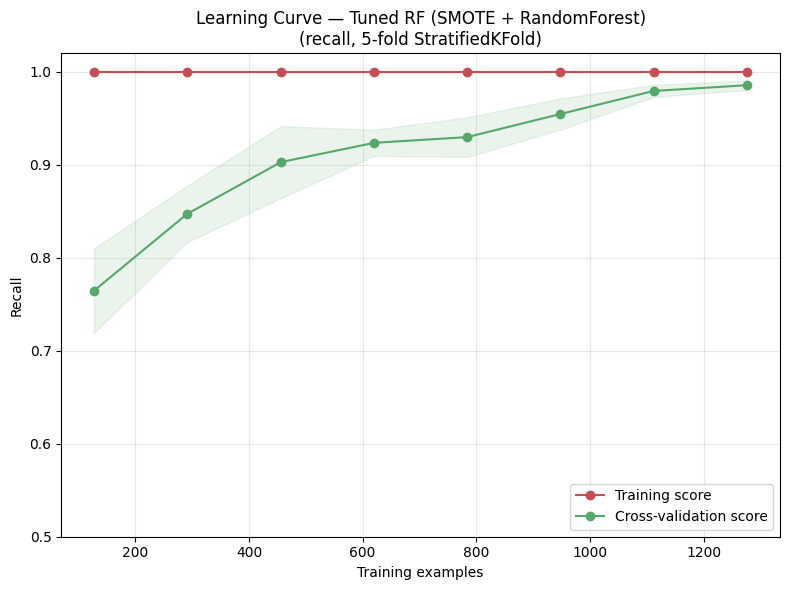

Final training recall:        1.0000
Final cross-val recall:       0.9855
Train–CV gap at full data:    0.0145  (low — generalises well)


In [133]:
# Random forest learning curve — uses the BEST tuned RF configuration (Section 8)
# Shows training vs. cross-validation score as training data grows.
# A small, closing gap = good generalisation (no overfitting).
from sklearn.base import clone
from sklearn.model_selection import learning_curve, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# --- Pick the best RF estimator -------------------------------------------------
# Prefer the tuned pipeline from Section 8; fall back to a sensible SMOTE+RF setup.
try:
    rf_best = clone(best_estimators['Random Forest'])
    rf_label = 'Tuned RF (SMOTE + RandomForest)'
except (NameError, KeyError):
    rf_best = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ])
    rf_label = 'RF (SMOTE + RandomForest, defaults)'

# --- Generate the learning curve ------------------------------------------------
SCORING = 'recall'   # swap to 'recall' to track PCOS sensitivity instead
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 8)

train_sizes, train_scores, test_scores = learning_curve(
    rf_best, X_train_full, y_train_full,
    train_sizes=train_sizes, cv=cv, scoring=SCORING,
    n_jobs=-1, shuffle=True, random_state=42
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
test_mean,  test_std  = test_scores.mean(axis=1),  test_scores.std(axis=1)

# --- Plot -----------------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.12, color='#C44E52')
plt.fill_between(train_sizes, test_mean  - test_std,  test_mean  + test_std,  alpha=0.12, color='#55A868')
plt.plot(train_sizes, train_mean, 'o-', color='#C44E52', label='Training score')
plt.plot(train_sizes, test_mean,  'o-', color='#55A868', label='Cross-validation score')
plt.title(f'Learning Curve — {rf_label}\n({SCORING}, 5-fold StratifiedKFold)')
plt.xlabel('Training examples')
plt.ylabel(SCORING.capitalize())
plt.ylim(0.5, 1.02)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Numeric overfitting check --------------------------------------------------
final_gap = train_mean[-1] - test_mean[-1]
print(f'Final training {SCORING}:        {train_mean[-1]:.4f}')
print(f'Final cross-val {SCORING}:       {test_mean[-1]:.4f}')
print(f'Train–CV gap at full data:    {final_gap:.4f}  '
      f'({"low — generalises well" if final_gap < 0.05 else "watch for overfitting"})')